In [1]:
# For Data Processing
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image, ImageEnhance
import gc

# For ML Models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img
import keras
from keras import layers
from keras import ops

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
from tqdm import tqdm
import os
import random

2025-10-21 05:02:01.973263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761022922.138681      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761022922.195009      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
!pip install tensorflow==2.12.0 tf-keras-vis==0.8.0

ERROR: Ignored the following versions that require a different python version: 0.2.0 Requires-Python >=3.5, <3.8; 0.2.1 Requires-Python >=3.5, <3.8; 0.2.3 Requires-Python >=3.5, <3.8; 0.2.4 Requires-Python >=3.5, <=3.8; 0.2.5 Requires-Python >=3.5, <3.9; 0.3.1 Requires-Python >=3.5, <3.9; 0.3.2 Requires-Python >=3.5, <3.9; 0.3.3 Requires-Python >=3.5, <3.9; 0.4.0 Requires-Python >=3.5, <3.9; 0.5.0 Requires-Python >=3.5, <3.9; 0.5.2 Requires-Python >=3.5, <3.9; 0.5.3 Requires-Python >=3.5, <3.9; 0.5.4 Requires-Python >=3.5, <3.9; 0.5.5 Requires-Python >=3.6, <3.9; 0.6.0 Requires-Python >=3.6, <3.10; 0.6.1 Requires-Python >=3.6, <3.10; 0.6.2 Requires-Python >=3.6, <3.10; 0.7.0 Requires-Python >=3.6, <3.10; 0.7.1 Requires-Python >=3.6, <3.10; 0.7.2 Requires-Python >=3.6, <3.10; 0.8.0 Requires-Python >=3.6, <3.10; 0.8.1 Requires-Python >=3.7, <3.11
ERROR: Could not find a version that satisfies the requirement tf-keras-vis==0.8.0 (from versions: 0.0.1, 0.1.0, 0.8.2, 0.8.3, 0.8.4, 0.8.5, 0.

In [3]:
import os
from sklearn.utils import shuffle

train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'

train_paths = []
train_labels = []

# 1️⃣ Sort class folders alphabetically
class_folders = sorted([f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))])

print("✅ Classes in training set:", class_folders)

# 2️⃣ Loop through folders and images, store string labels
for label in class_folders:
    folder_path = os.path.join(train_dir, label)
    images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    for img in images:
        train_paths.append(os.path.join(folder_path, img))
        train_labels.append(label)  # store string label

# 3️⃣ Shuffle dataset (optional)
train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

print("✅ Number of training images:", len(train_paths))

✅ Classes in training set: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
✅ Number of training images: 13927


In [4]:
import os
from sklearn.utils import shuffle

test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing'
test_paths = []
test_labels = []

# 1️⃣ Sort class folders alphabetically (same order as training)
class_folders = sorted([f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))])

print("✅ Classes in test set:", class_folders)

# 2️⃣ Loop through folders and images, store string labels
for label in class_folders:
    folder_path = os.path.join(test_dir, label)
    images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    for img in images:
        test_paths.append(os.path.join(folder_path, img))
        test_labels.append(label)  # store **string label**

# 3️⃣ Shuffle dataset (optional)
test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)

print("✅ Number of test images:", len(test_paths))

✅ Classes in test set: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
✅ Number of test images: 3961


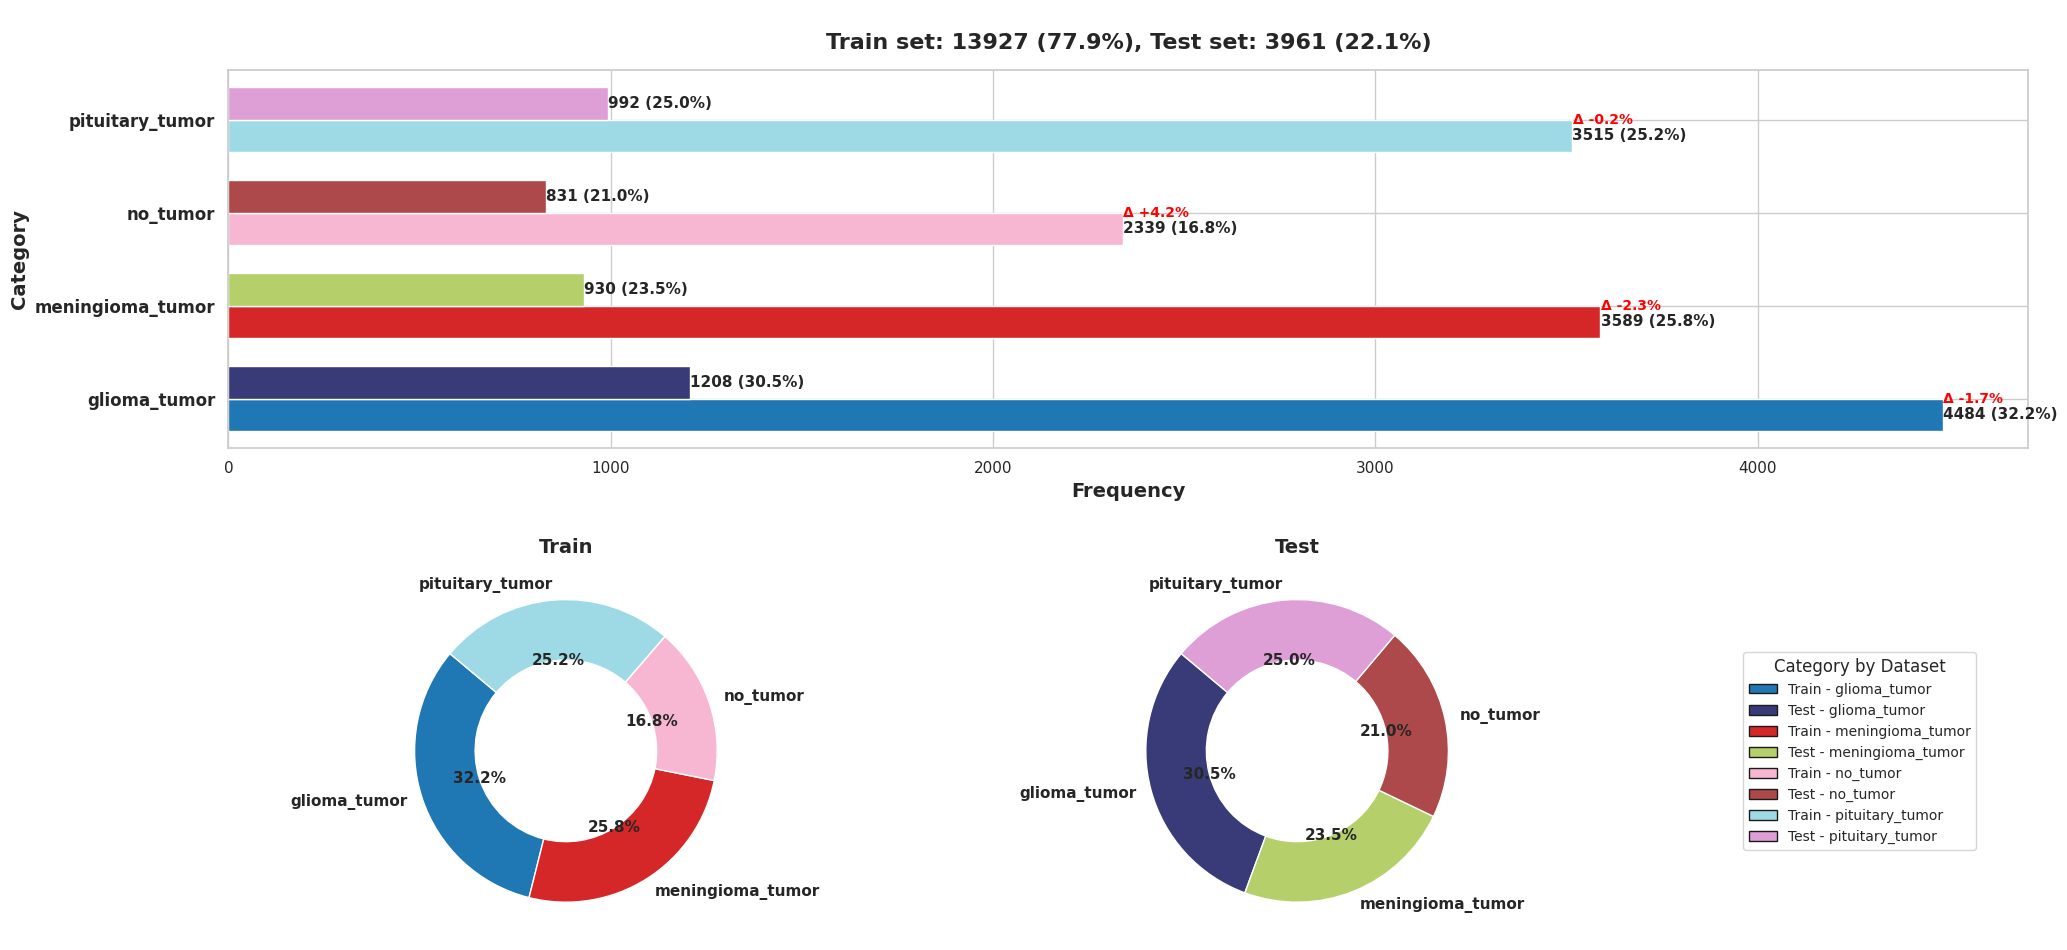

✅ Figure saved as 'Dataset_Distribution.png'


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.patches import Patch
import matplotlib

def plot_distribution(train_array, test_array=None, title="Category Distribution", output_file="dataset_overview.png"):
    sns.set_theme(style="whitegrid")

    # ---------------- Compute frequencies ----------------
    def compute_freq(array):
        hist = Counter(array)
        categories = sorted(hist.keys(), key=lambda x: hist[x], reverse=True)
        freqs = [hist[cat] for cat in categories]
        df = pd.DataFrame({"Category": categories, "Frequency": freqs})
        df['Percentage'] = df['Frequency'] / df['Frequency'].sum() * 100
        return df

    train_df = compute_freq(train_array)
    total_train = len(train_array)

    if test_array is not None:
        test_df = compute_freq(test_array)
        total_test = len(test_array)
        merged_df = pd.merge(train_df, test_df, on="Category", how="outer", suffixes=("_train", "_test")).fillna(0)
        categories = merged_df['Category'].tolist()
        freqs_train = merged_df['Frequency_train'].tolist()
        freqs_test = merged_df['Frequency_test'].tolist()
        perc_train = merged_df['Percentage_train'].tolist()
        perc_test = merged_df['Percentage_test'].tolist()
        diff_perc = [p_test - p_train for p_train, p_test in zip(perc_train, perc_test)]
        ratio_text = f"Train set: {total_train} ({total_train/(total_train+total_test)*100:.1f}%), " \
                     f"Test set: {total_test} ({total_test/(total_train+total_test)*100:.1f}%)"
    else:
        categories = train_df['Category'].tolist()
        freqs_train = train_df['Frequency'].tolist()
        perc_train = train_df['Percentage'].tolist()
        freqs_test = perc_test = diff_perc = None
        ratio_text = f"Train set: {total_train} (100%)"

    num_cats = len(categories)
    colors_train = matplotlib.cm.tab20(np.linspace(0, 1, num_cats))
    colors_test = matplotlib.cm.tab20b(np.linspace(0, 1, num_cats))

    # ---------------- Layout ----------------
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[2, 2], width_ratios=[2, 2, 1], hspace=0.3, wspace=0.1)

    # ---------------- Horizontal Bar Chart (Top row) ----------------
    ax_bar = fig.add_subplot(gs[0, :])
    y_pos = np.arange(num_cats)
    bar_width = 0.35

    if test_array is not None:
        ax_bar.barh(y_pos - bar_width/2, freqs_train, height=bar_width, color=colors_train)
        ax_bar.barh(y_pos + bar_width/2, freqs_test, height=bar_width, color=colors_test)
        for i, (f_train, f_test, p_train, p_test, d) in enumerate(zip(freqs_train, freqs_test, perc_train, perc_test, diff_perc)):
            ax_bar.text(f_train + 0.5, i - bar_width/2, f"{f_train} ({p_train:.1f}%)", va='center', fontsize=11, fontweight='bold')
            ax_bar.text(f_test + 0.5, i + bar_width/2, f"{f_test} ({p_test:.1f}%)", va='center', fontsize=11, fontweight='bold')
            ax_bar.text(max(f_train, f_test)+2, i, f"Δ {d:+.1f}%", va='center', fontsize=10, color='red', fontweight='bold')
    else:
        ax_bar.barh(categories, freqs_train, color=colors_train)
        for i, (f, p) in enumerate(zip(freqs_train, perc_train)):
            ax_bar.text(f + 0.5, i, f"{f} ({p:.1f}%)", va='center', fontsize=11, fontweight='bold')

    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(categories, fontsize=12, fontweight='bold')
    ax_bar.set_xlabel("Frequency", fontsize=14, fontweight='bold')
    ax_bar.set_ylabel("Category", fontsize=14, fontweight='bold')
    ax_bar.set_title("", fontsize=16, fontweight='bold')

    # ---------------- Donut Charts and Legend (Bottom row) ----------------
    def draw_donut(ax, freqs, categories, colors, set_name="Train"):
        wedges, texts, autotexts = ax.pie(freqs, labels=categories, autopct='%1.1f%%',
                                          startangle=140, colors=colors,
                                          wedgeprops=dict(width=0.4, edgecolor='w'),
                                          textprops={'fontsize':11, 'fontweight':'bold'})
        ax.set_title(f"{set_name}", fontsize=14, fontweight='bold')

    # Train Donut
    ax_donut_train = fig.add_subplot(gs[1, 0])
    draw_donut(ax_donut_train, freqs_train, categories, colors_train, set_name="Train")

    # Test Donut
    ax_donut_test = fig.add_subplot(gs[1, 1])
    if test_array is not None:
        draw_donut(ax_donut_test, freqs_test, categories, colors_test, set_name="Test")
    else:
        ax_donut_test.axis('off')

    # Legend
    ax_legend = fig.add_subplot(gs[1, 2])
    ax_legend.axis('off')
    legend_elements = []
    if test_array is not None:
        for i, cat in enumerate(categories):
            legend_elements.append(Patch(facecolor=colors_train[i], edgecolor='k', label=f"Train - {cat}"))
            legend_elements.append(Patch(facecolor=colors_test[i], edgecolor='k', label=f"Test - {cat}"))
    else:
        for i, cat in enumerate(categories):
            legend_elements.append(Patch(facecolor=colors_train[i], edgecolor='k', label=f"Train - {cat}"))
    ax_legend.legend(handles=legend_elements, fontsize=10, title="Category by Dataset", title_fontsize=12, loc='center')

    # ---------------- Overall Title ----------------
    fig.suptitle(f"{title}\n{ratio_text}", fontsize=16, fontweight='bold')

    # Adjust layout manually for compactness
    plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05, hspace=0.25, wspace=0.05)

    # ---------------- Save Figure ----------------
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Figure saved as '{output_file}'")

# Example usage:
plot_distribution(train_labels, test_labels, title="", output_file="Dataset_Distribution.png")

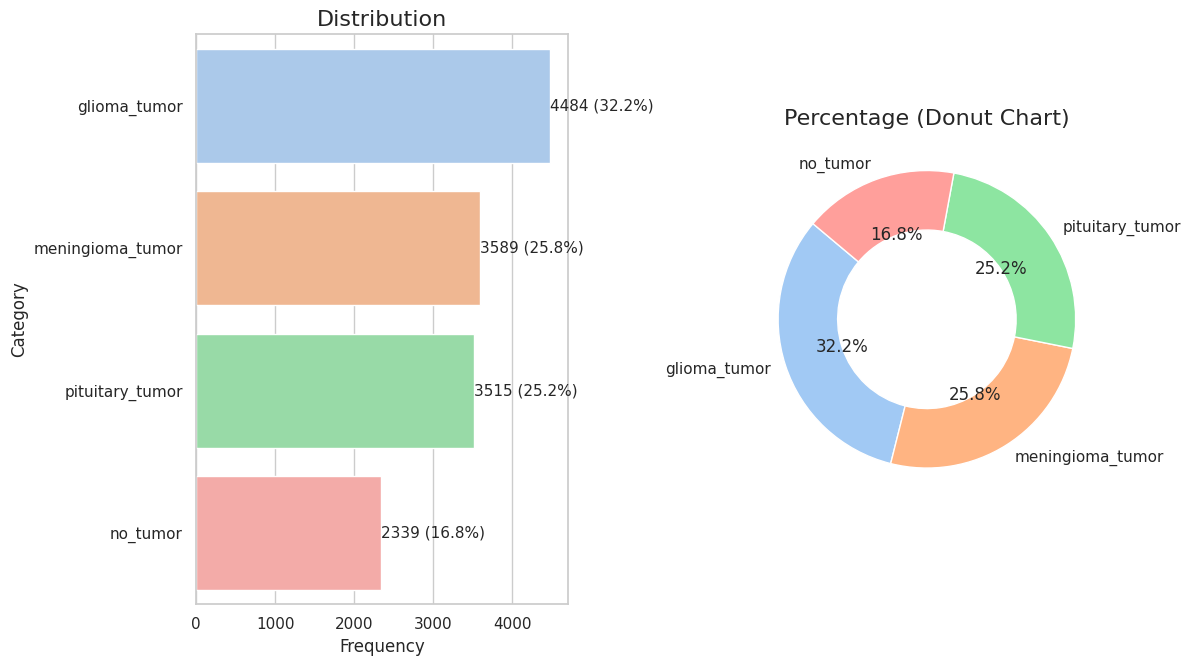

Figure saved as 'train.png'


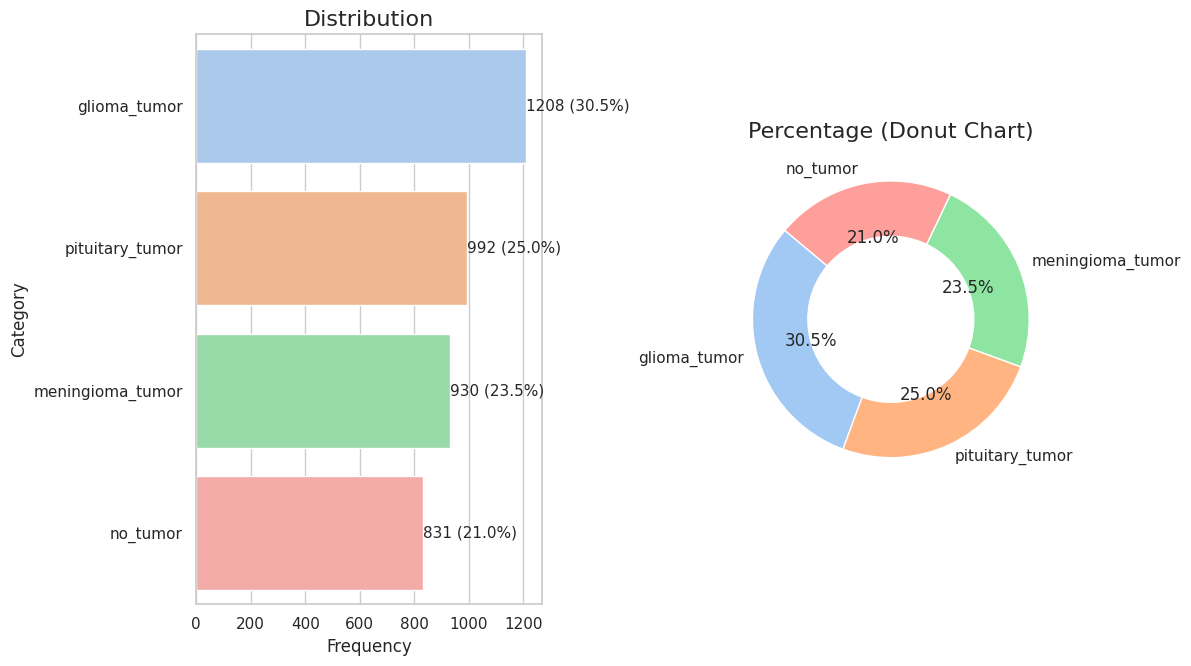

Figure saved as 'test.png'


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.express as px

def plot_distribution(array, title="Category Distribution", interactive=False, name = "set.png"):
    """
    Plots the distribution of categorical data as:
    - Horizontal bar chart
    - Donut chart (pie with a hole)
    Can also produce an interactive Plotly chart.

    Parameters:
    - array: list or array of categorical values
    - title: string, title of the plot
    - interactive: bool, if True, shows Plotly interactive chart
    """
    # Calculate frequencies
    hist = Counter(array)
    categories = sorted(hist.keys(), key=lambda x: hist[x], reverse=True)
    frequencies = [hist[cat] for cat in categories]
    df = pd.DataFrame({"Category": categories, "Frequency": frequencies})
    df['Percentage'] = df['Frequency'] / df['Frequency'].sum() * 100

    if interactive:
        # Interactive donut chart with Plotly
        fig = px.pie(df, 
                     names='Category', 
                     values='Frequency', 
                     title=title, 
                     hole=0.4,  # donut chart
                     color='Category',
                     color_discrete_sequence=px.colors.qualitative.Pastel)
        fig.update_traces(textposition='inside', textinfo='percent+label')
        fig.show()
    else:
        # Static matplotlib/seaborn plot
        sns.set_theme(style="whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

        # Horizontal Bar Chart
        sns.barplot(x="Frequency", y="Category", data=df, palette="pastel", ax=ax1)
        ax1.set_title("Distribution", fontsize=16)
        ax1.set_xlabel("Frequency")
        ax1.set_ylabel("Category")

        # Add count annotations
        for i, (freq, perc) in enumerate(zip(df['Frequency'], df['Percentage'])):
            ax1.text(freq + 0.5, i, f"{freq} ({perc:.1f}%)", va='center', fontsize=11)

        # Donut Chart
        colors = sns.color_palette("pastel", n_colors=len(categories))
        wedges, texts, autotexts = ax2.pie(
            frequencies, labels=categories, autopct="%1.1f%%",
            startangle=140, colors=colors, wedgeprops=dict(width=0.4)
        )
        ax2.set_title("Percentage (Donut Chart)", fontsize=16)

        # Overall title
        fig.suptitle(title, fontsize=18)
        plt.tight_layout()
        output_filename = name
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Figure saved as '{output_filename}'")


# =====================
# Example usage:
# train_labels = ['pituitary_tumor', 'no_tumor', 'glioma_tumor', 'meningioma_tumor', ...]
plot_distribution(train_labels, title="", interactive=False, name = "train.png")
plot_distribution(test_labels, title="", interactive=False, name = "test.png")

In [7]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

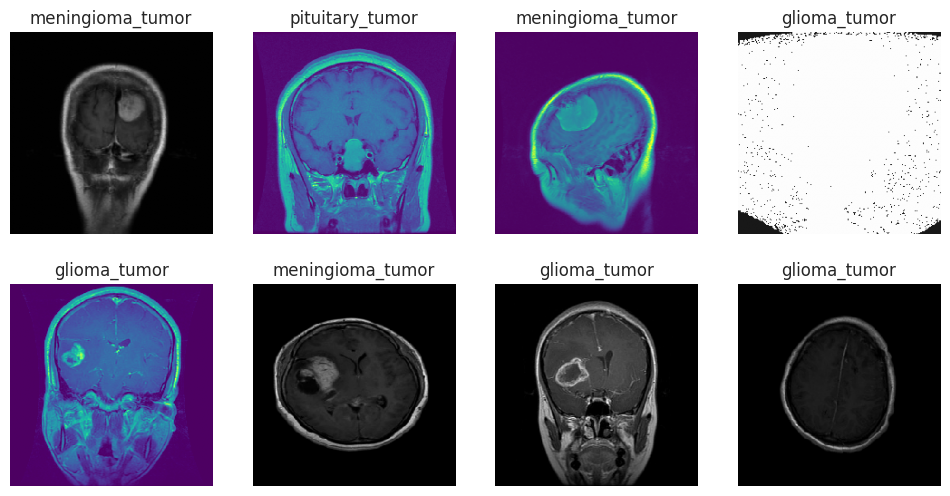

In [8]:
IMAGE_SIZE = 224

def open_images(paths):
    '''
    Given a list of paths to images, this function returns the images as arrays (after augmenting them)
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 10})
plt.show()

In [9]:
unique_labels = os.listdir(train_dir)

def encode_label(labels):
    encoded = []
    for x in labels:
        encoded.append(unique_labels.index(x))
    return np.array(encoded)

def decode_label(labels):
    decoded = []
    for x in labels:
        decoded.append(unique_labels[x])
    return np.array(decoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [10]:
!pip install vit-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.1 MB/s eta 0:00:00


In [11]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, Lambda
from vit_keras import vit
import tensorflow as tf

# --------------------------
# Helper: Create ViT Encoder
# --------------------------
def create_vit_encoder(model_type="b16", image_size=224, embed_dim=128):
    if model_type == "b16":
        base_model = vit.vit_b16(
            image_size=image_size,
            activation='softmax',
            pretrained=True,
            include_top=False,
            pretrained_top=False
        )
    else:
        base_model = vit.vit_b32(
            image_size=image_size,
            activation='softmax',
            pretrained=True,
            include_top=False,
            pretrained_top=False
        )
    # Freeze layers
    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers[-3:]:
        layer.trainable = True

    inputs = Input(shape=(image_size, image_size, 3))
    x = base_model(inputs)
    x = Dropout(0.3)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(embed_dim)(x)
    outputs = Lambda(lambda t: tf.nn.l2_normalize(t, axis=-1))(x)
    return Model(inputs, outputs, name=f"vit_encoder_{model_type}")
# --------------------------
# Contrastive Loss (InfoNCE)
# --------------------------
def contrastive_loss(z1, z2, temperature=0.1):
    batch_size = tf.shape(z1)[0]
    logits = tf.matmul(z1, z2, transpose_b=True) / temperature
    labels = tf.range(batch_size)
    loss1 = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
    loss2 = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
    return tf.reduce_mean(loss1 + loss2) / 2.0

In [12]:
import tensorflow as tf
from tensorflow.keras import Model

# --------------------------
# Dual Encoder Model with Metrics
# --------------------------
class ContrastiveModel(Model):
    def __init__(self, encoder1, encoder2, temperature=0.1):
        super().__init__()
        self.encoder1 = encoder1
        self.encoder2 = encoder2
        self.temperature = temperature

        # Metrics trackers
        self.accuracy_metric = tf.keras.metrics.Mean(name="accuracy")
        self.f1_metric = tf.keras.metrics.Mean(name="f1_score")
        self.precision_metric = tf.keras.metrics.Mean(name="precision")
        self.recall_metric = tf.keras.metrics.Mean(name="recall")
        self.auc_metric = tf.keras.metrics.AUC(name="auc")

    def train_step(self, data):
        (x1, x2), y = data  # unpack the tuple properly

        with tf.GradientTape() as tape:
            z1 = self.encoder1(x1, training=True)
            z2 = self.encoder2(x2, training=True)
            loss = contrastive_loss(z1, z2, self.temperature)

        grads = tape.gradient(
            loss,
            self.encoder1.trainable_variables + self.encoder2.trainable_variables
        )
        self.optimizer.apply_gradients(
            zip(grads, self.encoder1.trainable_variables + self.encoder2.trainable_variables)
        )

        # ------------------------
        # Metrics
        # ------------------------
        sim_matrix = tf.matmul(z1, z2, transpose_b=True)
        pred = tf.cast(tf.argmax(sim_matrix, axis=1), tf.int32)
        true = tf.cast(tf.range(tf.shape(z1)[0]), tf.int32)
        accuracy = tf.reduce_mean(tf.cast(tf.equal(pred, true), tf.float32))

        # F1, Precision, Recall (batch-level)
        threshold = 0.5
        sim_flat = tf.reshape(sim_matrix, [-1])
        y_pred = tf.cast(sim_flat > threshold, tf.int32)
        y_true = tf.cast(tf.reshape(tf.eye(tf.shape(z1)[0], dtype=tf.int32), [-1]), tf.int32)

        tp = tf.reduce_sum(tf.cast(y_pred * y_true, tf.float32))
        fp = tf.reduce_sum(tf.cast(y_pred * (1 - y_true), tf.float32))
        fn = tf.reduce_sum(tf.cast((1 - y_pred) * y_true, tf.float32))

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        # Update AUC
        self.auc_metric.update_state(y_true, tf.sigmoid(sim_flat))
        auc = self.auc_metric.result()

        # Update metric trackers
        self.accuracy_metric.update_state(accuracy)
        self.f1_metric.update_state(f1)
        self.precision_metric.update_state(precision)
        self.recall_metric.update_state(recall)

        return {
            "loss": loss,
            "accuracy": self.accuracy_metric.result(),
            "f1_score": self.f1_metric.result(),
            "precision": self.precision_metric.result(),
            "recall": self.recall_metric.result(),
            "auc": auc
        }

    def test_step(self, data):
        (x1, x2), y = data  # unpack tuple properly

        z1 = self.encoder1(x1, training=False)
        z2 = self.encoder2(x2, training=False)
        loss = contrastive_loss(z1, z2, self.temperature)

        # ------------------------
        # Metrics
        # ------------------------
        sim_matrix = tf.matmul(z1, z2, transpose_b=True)
        pred = tf.cast(tf.argmax(sim_matrix, axis=1), tf.int32)
        true = tf.cast(tf.range(tf.shape(z1)[0]), tf.int32)
        accuracy = tf.reduce_mean(tf.cast(tf.equal(pred, true), tf.float32))

        threshold = 0.5
        sim_flat = tf.reshape(sim_matrix, [-1])
        y_pred = tf.cast(sim_flat > threshold, tf.int32)
        y_true = tf.cast(tf.reshape(tf.eye(tf.shape(z1)[0], dtype=tf.int32), [-1]), tf.int32)

        tp = tf.reduce_sum(tf.cast(y_pred * y_true, tf.float32))
        fp = tf.reduce_sum(tf.cast(y_pred * (1 - y_true), tf.float32))
        fn = tf.reduce_sum(tf.cast((1 - y_pred) * y_true, tf.float32))

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        # Update AUC
        self.auc_metric.update_state(y_true, tf.sigmoid(sim_flat))
        auc = self.auc_metric.result()

        return {
            "loss": loss,
            "accuracy": accuracy,
            "f1_score": f1,
            "precision": precision,
            "recall": recall,
            "auc": auc
        }


In [13]:
import numpy as np
import tensorflow as tf
import random

# --------------------------
# Dual-Encoder Contrastive Generator
# --------------------------
def contrastive_datagen(paths, labels=None, batch_size=12, epochs=1, image_size=224, training=True):
    """
    Generator for dual-encoder contrastive learning.

    Args:
        paths: list of image file paths
        labels: list of corresponding labels (optional, used for metrics)
        batch_size: number of images per batch
        epochs: number of times to loop over dataset
        image_size: resize images to image_size x image_size
        training: apply augmentation if True

    Yields:
        Tuple ((x1_batch, x2_batch), y_batch) for Keras.
        If labels are not provided, y_batch will be None.
    """
    for _ in range(epochs):
        # Shuffle dataset each epoch
        if labels is not None:
            combined = list(zip(paths, labels))
            random.shuffle(combined)
            paths_shuffled, labels_shuffled = zip(*combined)
        else:
            paths_shuffled = paths
            labels_shuffled = [None] * len(paths)

        for i in range(0, len(paths_shuffled), batch_size):
            batch_paths = paths_shuffled[i:i+batch_size]
            batch_labels = labels_shuffled[i:i+batch_size]

            # Load images
            batch_images = open_images(batch_paths)  # shape: (batch,H,W,3)

            x1_batch = []
            x2_batch = []

            for img in batch_images:
                if training:
                    # Two different augmented views
                    img1 = tf.image.random_flip_left_right(img)
                    img1 = tf.image.random_brightness(img1, 0.2)

                    img2 = tf.image.random_flip_left_right(img)
                    img2 = tf.image.random_brightness(img2, 0.2)
                else:
                    img1 = img2 = img

                x1_batch.append(img1)
                x2_batch.append(img2)

            # Convert to tensors
            x1_batch = tf.convert_to_tensor(np.array(x1_batch), dtype=tf.float32)
            x2_batch = tf.convert_to_tensor(np.array(x2_batch), dtype=tf.float32)

            # Encode labels if provided
            if labels is not None:
                y_batch = encode_label(batch_labels)
            else:
                y_batch = None

            # Yield as ((x1, x2), y)
            yield (x1_batch, x2_batch), y_batch


In [14]:
IMAGE_SIZE = 224
encoder_b16 = create_vit_encoder("b16", IMAGE_SIZE)
encoder_b32 = create_vit_encoder("b32", IMAGE_SIZE)

contrastive_model = ContrastiveModel(encoder_b16, encoder_b32)

I0000 00:00:1761022947.529087      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


347502902/347502902 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.11/dist-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


353253686/353253686 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.11/dist-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 12, 12 to 7, 7
  warnings.warn(


In [15]:
# =========================================================
# ✅ Fixed Memory-Optimized Training Cell (Kaggle Version)
# =========================================================

# ------------------- 2️⃣ Enable dynamic GPU memory growth (must be before TF ops) -------------------
import tensorflow as tf
import os, gc

# This must come BEFORE anything else that uses the GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled before initialization.")
    except RuntimeError as e:
        print("⚠ Could not set memory growth:", e)
else:
    print("⚠ No GPU detected. Training will run on CPU.")

# ------------------- Import remaining dependencies -------------------
import numpy as np
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import LambdaCallback

# ------------------- 3️⃣ Enable mixed precision -------------------
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision policy set (mixed_float16).")

# ------------------- Compile contrastive model -------------------
contrastive_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
print("✅ Contrastive model compiled successfully.")

# ------------------- Training parameters -------------------
batch_size = 8        # If still OOM -> reduce to 4
epochs = 20
steps = len(train_paths) // (batch_size)

# ------------------- 4️⃣ Memory cleanup callback -------------------
clear_mem = LambdaCallback(
    on_epoch_end=lambda epoch, logs: (
        gc.collect(),
        tf.keras.backend.clear_session(),
        print(f"🧹 Memory cleared after epoch no-{epoch+1}")
    )
)

# ------------------- Start Training -------------------
print("🚀 Starting contrastive training...")
history = contrastive_model.fit(
    contrastive_datagen(train_paths, train_labels,
                        batch_size=batch_size,
                        epochs=epochs,
                        image_size=224,
                        training=True),
    steps_per_epoch=steps,
    epochs=epochs,
    verbose=2,
    callbacks=[clear_mem]
)

print("✅ Training completed successfully!")

⚠ Could not set memory growth: Physical devices cannot be modified after being initialized
✅ Mixed precision policy set (mixed_float16).
✅ Contrastive model compiled successfully.
🚀 Starting contrastive training...
Epoch 1/20


I0000 00:00:1761023005.941994      74 service.cc:148] XLA service 0x7872bc01e2c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761023005.943093      74 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761023011.170371      74 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1761023059.800308      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


🧹 Memory cleared after epoch no-1
1740/1740 - 374s - 215ms/step - accuracy: 0.7591 - auc: 0.9496 - f1_score: 0.6378 - loss: 0.0000e+00 - precision: 0.5014 - recall: 0.9256
Epoch 2/20
🧹 Memory cleared after epoch no-2
1740/1740 - 326s - 187ms/step - accuracy: 0.8840 - auc: 0.9787 - f1_score: 0.7072 - loss: 0.0000e+00 - precision: 0.5590 - recall: 0.9904
Epoch 3/20
🧹 Memory cleared after epoch no-3
1740/1740 - 273s - 157ms/step - accuracy: 0.9138 - auc: 0.9845 - f1_score: 0.7113 - loss: 0.0000e+00 - precision: 0.5622 - recall: 0.9947
Epoch 4/20
🧹 Memory cleared after epoch no-4
1740/1740 - 267s - 153ms/step - accuracy: 0.9233 - auc: 0.9867 - f1_score: 0.7187 - loss: 0.0000e+00 - precision: 0.5706 - recall: 0.9970
Epoch 5/20
🧹 Memory cleared after epoch no-5
1740/1740 - 266s - 153ms/step - accuracy: 0.9312 - auc: 0.9881 - f1_score: 0.7208 - loss: 0.0000e+00 - precision: 0.5724 - recall: 0.9980
Epoch 6/20
🧹 Memory cleared after epoch no-6
1740/1740 - 264s - 152ms/step - accuracy: 0.9369 - 

In [16]:
# # ------------------- Compile contrastive model -------------------
# contrastive_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
# print("✅ Contrastive model compiled successfully.")

# # ------------------- Training parameters -------------------
# batch_size = 8        # If still OOM -> reduce to 4
# epochs = 20
# steps = len(train_paths) // (batch_size)


# # ------------------- Start Training -------------------
# print("🚀 Starting contrastive training...")
# history = contrastive_model.fit(
#     contrastive_datagen(train_paths, train_labels,
#                         batch_size=batch_size,
#                         epochs=epochs,
#                         image_size=224,
#                         training=True),
#     steps_per_epoch=steps,
#     epochs=epochs,
#     verbose=2 )

# print("✅ Training completed successfully!")

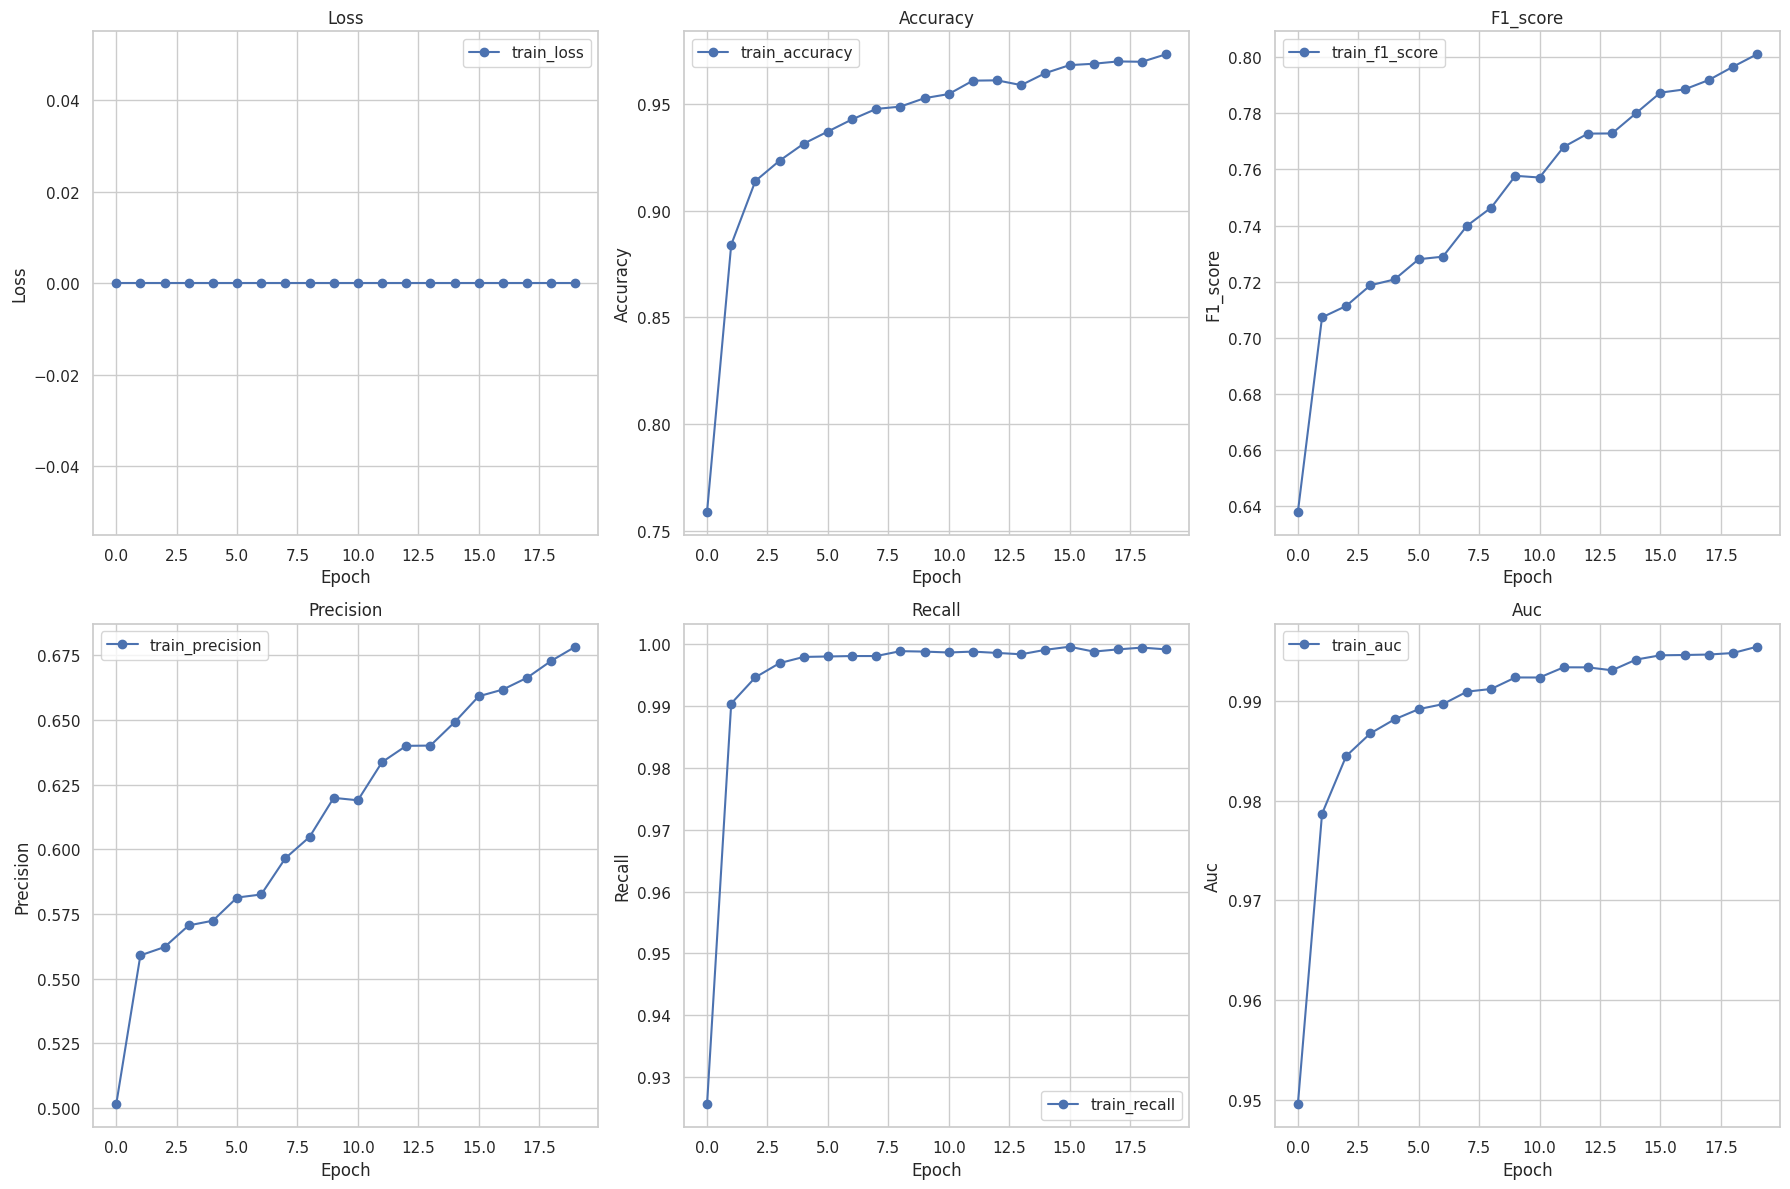

In [17]:
# --------------------------
# Plot all metrics
# --------------------------
metrics = ["loss", "accuracy", "f1_score", "precision", "recall", "auc"]

plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plt.plot(history.history[metric], label=f"train_{metric}", marker='o')
    #plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}", marker='x')
    plt.title(metric.capitalize())
    plt.xlabel("Epoch")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


--- Evaluation ---
Accuracy:  0.9500
F1-score:  0.9500
Precision: 0.9501
Recall:    0.9500
AUC:       0.9715


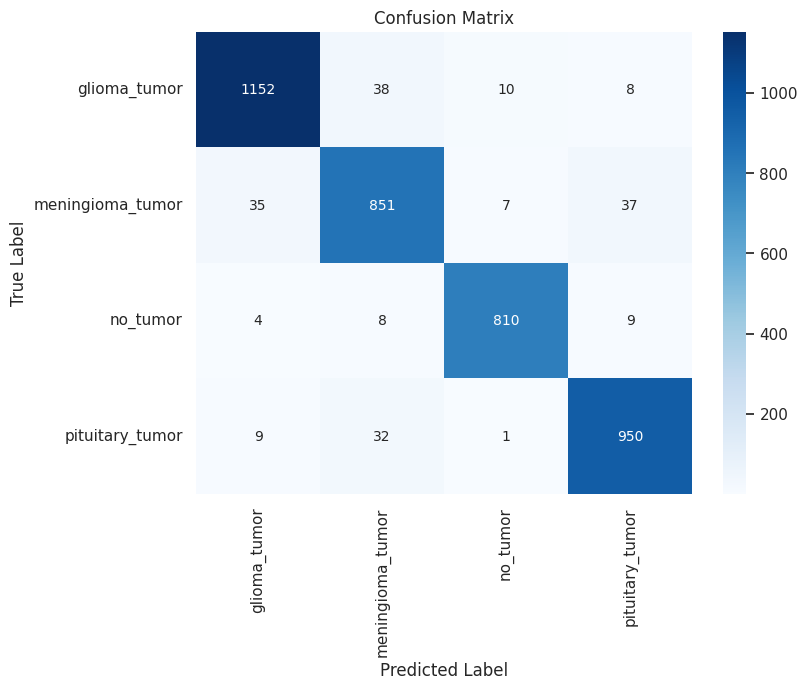

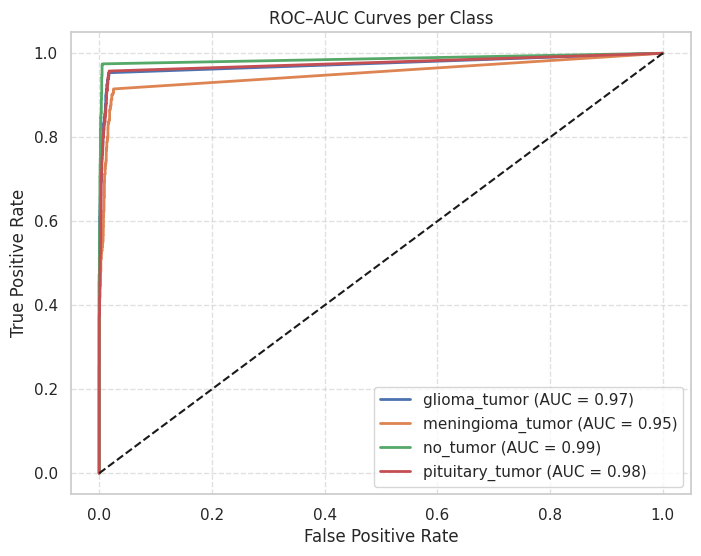

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# Compute gallery embeddings for full test set
# -------------------------------
def compute_gallery_embeddings(encoder, paths, labels, image_size=224):
    embeddings = []
    for img_path in paths:
        img = open_images([img_path])  # assumes open_images returns (1,H,W,3)
        emb = encoder(tf.convert_to_tensor(img, dtype=tf.float32), training=False).numpy()
        embeddings.append(emb[0])
    return np.array(embeddings), labels

gallery_embs, gallery_labels = compute_gallery_embeddings(
    contrastive_model.encoder1, test_paths, test_labels, image_size=224
)

# -------------------------------
# Evaluate on full test set
# -------------------------------
label_encoder = LabelEncoder()
label_encoder.fit(gallery_labels)

y_true, y_pred, similarities = [], [], []

for test_path, label in zip(test_paths, test_labels):
    # Load and preprocess query image
    query_img = open_images([test_path])
    query_tensor = tf.convert_to_tensor(query_img, dtype=tf.float32)
    
    if len(query_tensor.shape) == 3:
        query_tensor = tf.expand_dims(query_tensor, axis=0)

    # Generate query embedding
    query_emb = contrastive_model.encoder1(query_tensor, training=False).numpy()

    # Cosine similarity with gallery embeddings
    sim = cosine_similarity(query_emb, gallery_embs)[0]
    best_idx = np.argmax(sim)
    predicted_label = gallery_labels[best_idx]

    y_true.append(label)
    y_pred.append(predicted_label)
    similarities.append(sim[best_idx])

# -------------------------------
# Compute Metrics
# -------------------------------
y_true_int = label_encoder.transform(y_true)
y_pred_int = label_encoder.transform(y_pred)

accuracy = accuracy_score(y_true_int, y_pred_int)
f1 = f1_score(y_true_int, y_pred_int, average='weighted')
precision = precision_score(y_true_int, y_pred_int, average='weighted')
recall = recall_score(y_true_int, y_pred_int, average='weighted')

# Prepare data for AUC computation
num_classes = len(label_encoder.classes_)
y_true_onehot = np.zeros((len(y_true_int), num_classes))
for i, true_idx in enumerate(y_true_int):
    y_true_onehot[i, true_idx] = 1

y_scores = np.zeros_like(y_true_onehot, dtype=float)
for i, sim_val in enumerate(similarities):
    class_idx = label_encoder.transform([y_pred[i]])[0]
    y_scores[i, class_idx] = sim_val

auc_score = roc_auc_score(y_true_onehot, y_scores, multi_class='ovr', average='weighted')

# Print all metrics
print(f"\n--- Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc_score:.4f}")

# -------------------------------
# Confusion Matrix Visualization
# -------------------------------
cm = confusion_matrix(y_true_int, y_pred_int)
class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# -------------------------------
# ROC–AUC Curves per Class
# -------------------------------
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title('ROC–AUC Curves per Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [19]:
import os
import gc
import random
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------- Mixed Precision -------------------
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')  # 4️⃣

# ------------------- Parameters -------------------
NUM_CLIENTS = 2
NUM_ROUNDS = 10
BATCH_SIZE = 8
EPOCHS = 2
NUM_CLASSES = 4
TEST_SUBSET_SIZE = 50
CHECKPOINT_DIR = './checkpoints_contrastive'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ------------------- Prepare clients -------------------
clients = []
for i in range(NUM_CLIENTS):
    start = i * (len(train_paths) // NUM_CLIENTS)
    end = (i + 1) * (len(train_paths) // NUM_CLIENTS)
    clients.append((train_paths[start:end], train_labels[start:end]))


# ------------------- Metric stores -------------------
client_metrics = {i: {'loss': [], 'acc': []} for i in range(NUM_CLIENTS)}
global_metrics = {'acc': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

# ------------------- Helper: compute gallery embeddings batch-wise -------------------
def compute_gallery_embeddings(encoder, paths, labels, batch_size=2):
    embeddings = []
    lbls = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = open_images(batch_paths)
        emb = encoder(tf.convert_to_tensor(imgs, dtype=tf.float32), training=False).numpy()
        embeddings.append(emb)
        lbls.extend(labels[i:i+len(batch_paths)])
        del imgs, emb
        gc.collect()
        tf.keras.backend.clear_session()
    embeddings = np.vstack(embeddings)
    return embeddings, np.array(lbls)

# ------------------- Federated Training Loop -------------------
for round_num in range(NUM_ROUNDS):
    print(f"\n=== Federated Round {round_num+1}/{NUM_ROUNDS} ===")
    
    selected_idx = np.random.choice(NUM_CLIENTS, size=max(1, NUM_CLIENTS//2), replace=False)
    print("Selected clients:", selected_idx)
    
    collected_client_weights = []
    collected_client_sizes = []
    
    for i in range(NUM_CLIENTS):
        client_data, client_labels = clients[i]
        if i not in selected_idx:
            for key in client_metrics[i]:
                client_metrics[i][key].append(client_metrics[i][key][-1] if client_metrics[i][key] else np.nan)
            continue
        
        num_samples_client = len(client_data)
        print(f"> Training on client {i} (samples: {num_samples_client})")
        
        # ------------------- Scoped client training -------------------
        def train_client(client_data, client_labels):
            client_model = ContrastiveModel(encoder_b16, encoder_b32)
            client_model.compile(optimizer=Adam(learning_rate=1e-3))
            client_model.set_weights(contrastive_model.get_weights())
            
            steps_per_client = max(100, num_samples_client // (100 * BATCH_SIZE))
            for e in range(EPOCHS):
                print(f"\n--- Training Epoch {e+1}/{EPOCHS} ---")
                history = client_model.fit(
                    contrastive_datagen(client_data, client_labels, batch_size=BATCH_SIZE, epochs=1, training=True),
                    steps_per_epoch=steps_per_client,
                    verbose=2
                    )
            weights = client_model.get_weights()
            
            # Cleanup
            del client_model
            gc.collect()
            tf.keras.backend.clear_session()
            try: tf.config.experimental.reset_memory_stats('GPU:0')
            except: pass
            return weights, history

        client_weights, history = train_client(client_data, client_labels)
        client_metrics[i]['loss'].append(np.mean(history.history['loss']))
        client_metrics[i]['acc'].append(np.mean(history.history.get('sparse_categorical_accuracy', [np.nan])))
        
        collected_client_weights.append(client_weights)
        collected_client_sizes.append(num_samples_client)
    
    # ------------------- Weighted FedAvg -------------------
    if collected_client_weights:
        collected_client_sizes = np.array(collected_client_sizes, dtype=np.float32)
        size_weights = collected_client_sizes / collected_client_sizes.sum()
        new_weights = []
        num_layers = len(collected_client_weights[0])
        for layer_idx in range(num_layers):
            layer_shape = collected_client_weights[0][layer_idx].shape
            agg = np.zeros(layer_shape, dtype=np.float32)
            for cw, w in zip(collected_client_weights, size_weights):
                agg += cw[layer_idx].astype(np.float32) * w
            new_weights.append(agg)
        contrastive_model.set_weights(new_weights)
    
    # ------------------- Evaluate Global Model on test subset -------------------
    subset_test_paths = test_paths[:TEST_SUBSET_SIZE]
    subset_test_labels = test_labels[:TEST_SUBSET_SIZE]

    gallery_embs, gallery_labels = compute_gallery_embeddings(
        contrastive_model.encoder2, subset_test_paths, subset_test_labels, batch_size=BATCH_SIZE
    )

    y_true, y_pred, similarities = [], [], []
    for i in range(0, len(subset_test_paths), BATCH_SIZE):
        batch_paths = subset_test_paths[i:i+BATCH_SIZE]
        batch_labels = subset_test_labels[i:i+BATCH_SIZE]
        batch_imgs = open_images(batch_paths)
        query_embs = contrastive_model.encoder1(tf.convert_to_tensor(batch_imgs, dtype=tf.float32), training=False).numpy()
        
        for q_emb, true_label in zip(query_embs, batch_labels):
            sim = cosine_similarity(np.expand_dims(q_emb,0), gallery_embs)[0]
            best_idx = np.argmax(sim)
            y_pred.append(gallery_labels[best_idx])
            y_true.append(true_label)
            similarities.append(sim[best_idx])
        
        del batch_imgs, query_embs
        gc.collect()
        tf.keras.backend.clear_session()

    label_encoder = LabelEncoder()
    label_encoder.fit(gallery_labels)
    y_true_int = label_encoder.transform(y_true)
    y_pred_int = label_encoder.transform(y_pred)

    acc = accuracy_score(y_true_int, y_pred_int)
    prec = precision_score(y_true_int, y_pred_int, average='weighted', zero_division=0)
    rec = recall_score(y_true_int, y_pred_int, average='weighted', zero_division=0)
    f1 = f1_score(y_true_int, y_pred_int, average='weighted', zero_division=0)

    y_true_onehot = np.zeros((len(y_true_int), NUM_CLASSES))
    for i_, idx in enumerate(y_true_int):
        y_true_onehot[i_, idx] = 1
    y_scores = np.zeros_like(y_true_onehot, dtype=float)
    for i_, sim_val in enumerate(similarities):
        cls_idx = y_pred_int[i_]
        y_scores[i_, cls_idx] = sim_val
    auc_score = roc_auc_score(y_true_onehot, y_scores, multi_class='ovr', average='weighted')

    global_metrics['acc'].append(acc)
    global_metrics['precision'].append(prec)
    global_metrics['recall'].append(rec)
    global_metrics['f1'].append(f1)
    global_metrics['auc'].append(auc_score)

    print(f"Global model after round {round_num+1}: Acc={acc:.4f}, Prec={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}, AUC={auc_score:.4f}")

    # Save checkpoint
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'contrastive_model_round_{round_num+1}.h5')
    try: contrastive_model.save(ckpt_path)
    except: pass

    # ------------------- Round-level cleanup -------------------
    del gallery_embs, gallery_labels, y_true, y_pred, similarities, y_true_int, y_pred_int, y_true_onehot, y_scores
    gc.collect()
    tf.keras.backend.clear_session()

print("✅ Federated training with memory optimization and mixed precision completed.")


=== Federated Round 1/10 ===
Selected clients: [1]
> Training on client 1 (samples: 6963)

--- Training Epoch 1/2 ---
100/100 - 113s - 1s/step - accuracy: 0.9775 - auc: 0.9953 - f1_score: 0.8073 - loss: 0.0000e+00 - precision: 0.6880 - recall: 1.0000

--- Training Epoch 2/2 ---
100/100 - 18s - 177ms/step - accuracy: 0.9812 - auc: 0.9972 - f1_score: 0.7976 - loss: 0.0000e+00 - precision: 0.6736 - recall: 0.9987
Global model after round 1: Acc=0.9400, Prec=0.9406, Recall=0.9400, F1=0.9397, AUC=0.9658

=== Federated Round 2/10 ===
Selected clients: [0]
> Training on client 0 (samples: 6963)

--- Training Epoch 1/2 ---
100/100 - 115s - 1s/step - accuracy: 0.9688 - auc: 0.9953 - f1_score: 0.8043 - loss: 0.0000e+00 - precision: 0.6827 - recall: 0.9987

--- Training Epoch 2/2 ---
100/100 - 18s - 182ms/step - accuracy: 0.9675 - auc: 0.9951 - f1_score: 0.8003 - loss: 0.0000e+00 - precision: 0.6779 - recall: 0.9987
Global model after round 2: Acc=0.9800, Prec=0.9811, Recall=0.9800, F1=0.9799, A


--- Evaluation ---
Accuracy:  0.9591
F1-score:  0.9591
Precision: 0.9591
Recall:    0.9591
AUC:       0.9769


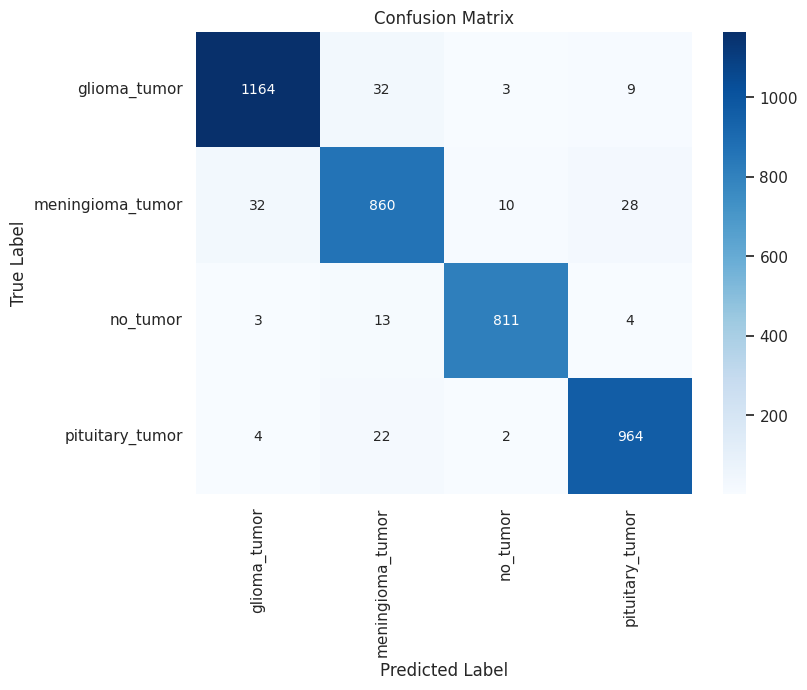

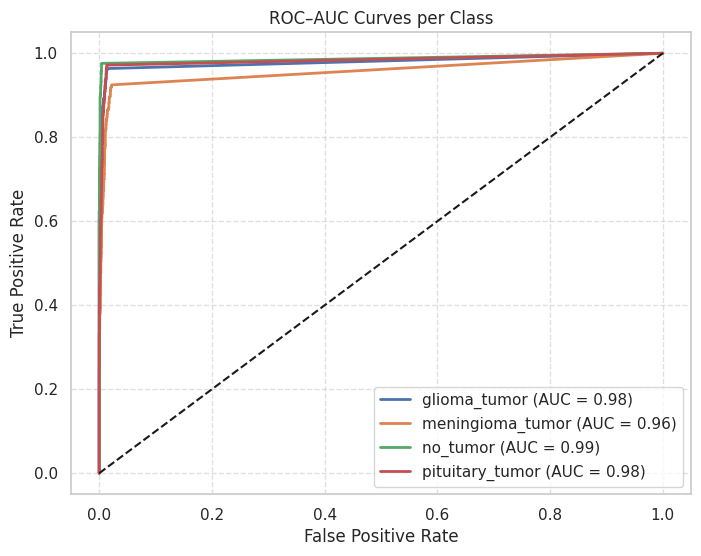

In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# Compute gallery embeddings for full test set
# -------------------------------
def compute_gallery_embeddings(encoder, paths, labels, image_size=224):
    embeddings = []
    for img_path in paths:
        img = open_images([img_path])  # assumes open_images returns (1,H,W,3)
        emb = encoder(tf.convert_to_tensor(img, dtype=tf.float32), training=False).numpy()
        embeddings.append(emb[0])
    return np.array(embeddings), labels

gallery_embs, gallery_labels = compute_gallery_embeddings(
    contrastive_model.encoder1, test_paths, test_labels, image_size=224
)

# -------------------------------
# Evaluate on full test set
# -------------------------------
label_encoder = LabelEncoder()
label_encoder.fit(gallery_labels)

y_true, y_pred, similarities = [], [], []

for test_path, label in zip(test_paths, test_labels):
    # Load and preprocess query image
    query_img = open_images([test_path])
    query_tensor = tf.convert_to_tensor(query_img, dtype=tf.float32)
    
    if len(query_tensor.shape) == 3:
        query_tensor = tf.expand_dims(query_tensor, axis=0)

    # Generate query embedding
    query_emb = contrastive_model.encoder1(query_tensor, training=False).numpy()

    # Cosine similarity with gallery embeddings
    sim = cosine_similarity(query_emb, gallery_embs)[0]
    best_idx = np.argmax(sim)
    predicted_label = gallery_labels[best_idx]

    y_true.append(label)
    y_pred.append(predicted_label)
    similarities.append(sim[best_idx])

# -------------------------------
# Compute Metrics
# -------------------------------
y_true_int = label_encoder.transform(y_true)
y_pred_int = label_encoder.transform(y_pred)

accuracy = accuracy_score(y_true_int, y_pred_int)
f1 = f1_score(y_true_int, y_pred_int, average='weighted')
precision = precision_score(y_true_int, y_pred_int, average='weighted')
recall = recall_score(y_true_int, y_pred_int, average='weighted')

# Prepare data for AUC computation
num_classes = len(label_encoder.classes_)
y_true_onehot = np.zeros((len(y_true_int), num_classes))
for i, true_idx in enumerate(y_true_int):
    y_true_onehot[i, true_idx] = 1

y_scores = np.zeros_like(y_true_onehot, dtype=float)
for i, sim_val in enumerate(similarities):
    class_idx = label_encoder.transform([y_pred[i]])[0]
    y_scores[i, class_idx] = sim_val

auc_score = roc_auc_score(y_true_onehot, y_scores, multi_class='ovr', average='weighted')

# Print all metrics
print(f"\n--- Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc_score:.4f}")

# -------------------------------
# Confusion Matrix Visualization
# -------------------------------
cm = confusion_matrix(y_true_int, y_pred_int)
class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# -------------------------------
# ROC–AUC Curves per Class
# -------------------------------
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title('ROC–AUC Curves per Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
# # =========================================================
# # ✅ Fixed Memory-Optimized Training Cell (Kaggle Version)
# # =========================================================

# # ------------------- 2️⃣ Enable dynamic GPU memory growth (must be before TF ops) -------------------
# import tensorflow as tf
# import os, gc

# # This must come BEFORE anything else that uses the GPU
# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     try:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#         print("✅ GPU memory growth enabled before initialization.")
#     except RuntimeError as e:
#         print("⚠ Could not set memory growth:", e)
# else:
#     print("⚠ No GPU detected. Training will run on CPU.")

# # ------------------- Import remaining dependencies -------------------
# import numpy as np
# from tensorflow.keras import mixed_precision
# from tensorflow.keras.callbacks import LambdaCallback

# # ------------------- 3️⃣ Enable mixed precision -------------------
# mixed_precision.set_global_policy('mixed_float16')
# print("✅ Mixed precision policy set (mixed_float16).")

# # ------------------- Compile contrastive model -------------------
# contrastive_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
# print("✅ Contrastive model compiled successfully.")

# # ------------------- Training parameters -------------------
# batch_size = 8        # If still OOM -> reduce to 4
# epochs = 20
# steps = len(train_paths) // (batch_size * 2)

# # ------------------- 4️⃣ Memory cleanup callback -------------------
# clear_mem = LambdaCallback(
#     on_epoch_end=lambda epoch, logs: (
#         gc.collect(),
#         tf.keras.backend.clear_session(),
#         print(f"🧹 Memory cleared after epoch {epoch+1}")
#     )
# )

# # ------------------- Start Training -------------------
# print("🚀 Starting contrastive training...")
# history = contrastive_model.fit(
#     contrastive_datagen(train_paths, train_labels,
#                         batch_size=batch_size,
#                         epochs=epochs,
#                         image_size=224,
#                         training=True),
#     steps_per_epoch=steps,
#     epochs=epochs,
#     verbose=2,
#     callbacks=[clear_mem]
# )

# print("✅ Training completed successfully!")

In [22]:
# # --------------------------
# # Plot all metrics
# # --------------------------
# metrics = ["loss", "accuracy", "f1_score", "precision", "recall", "auc"]

# plt.figure(figsize=(18, 12))
# for i, metric in enumerate(metrics):
#     plt.subplot(2, 3, i+1)
#     plt.plot(history.history[metric], label=f"train_{metric}", marker='o')
#     #plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}", marker='x')
#     plt.title(metric.capitalize())
#     plt.xlabel("Epoch")
#     plt.ylabel(metric.capitalize())
#     plt.legend()
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

In [23]:
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import (
#     accuracy_score, f1_score, precision_score, recall_score,
#     roc_auc_score, confusion_matrix, roc_curve, auc
# )
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics.pairwise import cosine_similarity

# # -------------------------------
# # Compute gallery embeddings for full test set
# # -------------------------------
# def compute_gallery_embeddings(encoder, paths, labels, image_size=224):
#     embeddings = []
#     for img_path in paths:
#         img = open_images([img_path])  # assumes open_images returns (1,H,W,3)
#         emb = encoder(tf.convert_to_tensor(img, dtype=tf.float32), training=False).numpy()
#         embeddings.append(emb[0])
#     return np.array(embeddings), labels

# gallery_embs, gallery_labels = compute_gallery_embeddings(
#     contrastive_model.encoder1, test_paths, test_labels, image_size=224
# )

# # -------------------------------
# # Evaluate on full test set
# # -------------------------------
# label_encoder = LabelEncoder()
# label_encoder.fit(gallery_labels)

# y_true, y_pred, similarities = [], [], []

# for test_path, label in zip(test_paths, test_labels):
#     # Load and preprocess query image
#     query_img = open_images([test_path])
#     query_tensor = tf.convert_to_tensor(query_img, dtype=tf.float32)
    
#     if len(query_tensor.shape) == 3:
#         query_tensor = tf.expand_dims(query_tensor, axis=0)

#     # Generate query embedding
#     query_emb = contrastive_model.encoder1(query_tensor, training=False).numpy()

#     # Cosine similarity with gallery embeddings
#     sim = cosine_similarity(query_emb, gallery_embs)[0]
#     best_idx = np.argmax(sim)
#     predicted_label = gallery_labels[best_idx]

#     y_true.append(label)
#     y_pred.append(predicted_label)
#     similarities.append(sim[best_idx])

# # -------------------------------
# # Compute Metrics
# # -------------------------------
# y_true_int = label_encoder.transform(y_true)
# y_pred_int = label_encoder.transform(y_pred)

# accuracy = accuracy_score(y_true_int, y_pred_int)
# f1 = f1_score(y_true_int, y_pred_int, average='weighted')
# precision = precision_score(y_true_int, y_pred_int, average='weighted')
# recall = recall_score(y_true_int, y_pred_int, average='weighted')

# # Prepare data for AUC computation
# num_classes = len(label_encoder.classes_)
# y_true_onehot = np.zeros((len(y_true_int), num_classes))
# for i, true_idx in enumerate(y_true_int):
#     y_true_onehot[i, true_idx] = 1

# y_scores = np.zeros_like(y_true_onehot, dtype=float)
# for i, sim_val in enumerate(similarities):
#     class_idx = label_encoder.transform([y_pred[i]])[0]
#     y_scores[i, class_idx] = sim_val

# auc_score = roc_auc_score(y_true_onehot, y_scores, multi_class='ovr', average='weighted')

# # Print all metrics
# print(f"\n--- Evaluation ---")
# print(f"Accuracy:  {accuracy:.4f}")
# print(f"F1-score:  {f1:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"AUC:       {auc_score:.4f}")

# # -------------------------------
# # Confusion Matrix Visualization
# # -------------------------------
# cm = confusion_matrix(y_true_int, y_pred_int)
# class_names = label_encoder.classes_

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=class_names, yticklabels=class_names)
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.show()

# # -------------------------------
# # ROC–AUC Curves per Class
# # -------------------------------
# plt.figure(figsize=(8, 6))
# for i, class_name in enumerate(class_names):
#     fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_scores[:, i])
#     roc_auc = auc(fpr, tpr)
#     plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

# plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
# plt.title('ROC–AUC Curves per Class')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.legend(loc='lower right')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

In [24]:
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import os, random
# import matplotlib.image as mpimg
# from tensorflow.keras.preprocessing import image
# from tensorflow.keras.models import load_model
# from sklearn.metrics.pairwise import cosine_similarity

# # -------------------------------
# # Paths
# # -------------------------------
# train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'
# test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing/'

# # -------------------------------
# # Label Mapping
# # -------------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# class_to_idx = {label: idx for idx, label in enumerate(fixed_label_order)}
# idx_to_class = {idx: label for label, idx in class_to_idx.items()}

# print("✅ Fixed class-to-index mapping:")
# for k, v in class_to_idx.items():
#     print(f"  {k}: {v}")

# # -------------------------------
# # Helper Functions
# # -------------------------------
# def preprocess_image(img_path, target_size=(224,224)):
#     """Load and preprocess image"""
#     img = image.load_img(img_path, target_size=target_size)
#     img_array = image.img_to_array(img)
#     img_array = np.expand_dims(img_array, axis=0)
#     return img_array / 255.0

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return folder_name if folder_name in fixed_label_order else "Unknown"

# def get_random_test_images(test_dir, n=20):
#     all_image_paths = []
#     for folder_name in fixed_label_order:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images_in_folder = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ]
#             all_image_paths.extend(images_in_folder)
#     selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
#     print(f"\n📌 Selected {len(selected)} random test images:")
#     for p in selected:
#         print("   -", p)
#     return selected

# # -------------------------------
# # Feature Extractor for Similarity
# # -------------------------------
# def get_embedding(model, img_array):
#     """Extract normalized embedding"""
#     emb = model(img_array, training=False).numpy()
#     return emb / np.linalg.norm(emb)

# # -------------------------------
# # Build Gallery Embeddings
# # -------------------------------
# def build_gallery_embeddings(model, train_dir):
#     gallery_embs, gallery_labels = [], []
#     for label in fixed_label_order:
#         folder_path = os.path.join(train_dir, label)
#         imgs = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
#         imgs = random.sample(imgs, min(20, len(imgs)))  # sample few for speed
#         for path in imgs:
#             arr = preprocess_image(path)
#             emb = get_embedding(model, arr)
#             gallery_embs.append(emb)
#             gallery_labels.append(label)
#     return np.vstack(gallery_embs), np.array(gallery_labels)

# print("\n🔹 Building gallery embeddings...")
# gallery_embs, gallery_labels = build_gallery_embeddings(contrastive_model.encoder1, train_dir)
# print(f"✅ Gallery built: {gallery_embs.shape}")

# # -------------------------------
# # Saliency + Similarity Visualization
# # -------------------------------
# def plot_contrastive_saliency(model, img_paths, gallery_embs, gallery_labels, save_dir="saliency_outputs"):
#     os.makedirs(save_dir, exist_ok=True)

#     for idx, img_path in enumerate(img_paths):
#         print(f"\n🖼 Image {idx+1}/{len(img_paths)}: {img_path}")

#         # Preprocess
#         img_array = preprocess_image(img_path)
#         actual_label = get_actual_label(img_path)

#         # Get embedding
#         query_emb = get_embedding(model, img_array)
#         sims = cosine_similarity(query_emb, gallery_embs)[0]

#         # Get most similar gallery sample
#         best_idx = np.argmax(sims)
#         best_label = gallery_labels[best_idx]
#         best_score = sims[best_idx]

#         print("🔹 Top-3 Similar Classes:")
#         top_indices = np.argsort(sims)[::-1][:3]
#         for rank, i in enumerate(top_indices, start=1):
#             print(f"   {rank}. {gallery_labels[i]} → cos={sims[i]:.4f}")

#         # Compute saliency based on similarity output
#         img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
#         with tf.GradientTape() as tape:
#             tape.watch(img_tensor)
#             emb = model(img_tensor)
#             sim_score = tf.reduce_sum(emb * tf.constant(gallery_embs[best_idx:best_idx+1], dtype=tf.float32))
#         grads = tape.gradient(sim_score, img_tensor)[0].numpy()
#         saliency = np.max(np.abs(grads), axis=-1)
#         saliency -= saliency.min()
#         saliency /= (saliency.max() + 1e-8)

#         # Original image
#         orig_img = image.load_img(img_path, target_size=(224,224))

#         # Plot figure
#         fig, axes = plt.subplots(1, 2, figsize=(10,4))

#         # Left: Original
#         axes[0].imshow(orig_img)
#         axes[0].axis('off')
#         axes[0].set_title(f"Pred: {best_label} ({best_score:.2f})\nActual: {actual_label}",
#                           fontsize=11, fontweight='bold')

#         # Right: Saliency
#         axes[1].imshow(orig_img)
#         sal = axes[1].imshow(saliency, cmap='jet', alpha=0.45)
#         axes[1].axis('off')
#         axes[1].set_title("Saliency Overlay", fontsize=11, fontweight='bold')

#         # Colorbar
#         cbar = fig.colorbar(sal, ax=axes[1], fraction=0.046, pad=0.04)
#         cbar.ax.tick_params(labelsize=8)
#         cbar.set_label('Saliency Intensity', fontsize=9, fontweight='bold')

#         plt.tight_layout()
#         save_path = os.path.join(save_dir, f"contrastive_saliency_{idx+1}.png")
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         plt.close(fig)

#         print(f"✅ Saved: {save_path}")
#         print(f"🔸 Prediction: {best_label} ({best_score:.4f}) | Actual: {actual_label}")

#     # Display saved results inline
#     print("\n📌 Displaying generated saliency maps:")
#     for idx in range(len(img_paths)):
#         img_file = os.path.join(save_dir, f"contrastive_saliency_{idx+1}.png")
#         img = mpimg.imread(img_file)
#         plt.figure(figsize=(8,4))
#         plt.imshow(img)
#         plt.axis('off')
#         plt.title(f"Saliency {idx+1}", fontsize=12, fontweight='bold')
#         plt.show()

# # -------------------------------
# # Run Visualization
# # -------------------------------
# img_paths = get_random_test_images(test_dir, n=10)
# plot_contrastive_saliency(contrastive_model.encoder1, img_paths, gallery_embs, gallery_labels)
# img_paths = get_random_test_images(test_dir, n=10)
# plot_contrastive_saliency(contrastive_model.encoder2, img_paths, gallery_embs, gallery_labels)

In [25]:
# import os
# import random
# import numpy as np
# import tensorflow as tf
# from PIL import Image
# import matplotlib.pyplot as plt
# from sklearn.metrics.pairwise import cosine_similarity

# # -----------------------------
# # Paths
# # -----------------------------
# train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'
# test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing/'

# # -----------------------------
# # Fixed Label Order
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# class_to_idx = {label: idx for idx, label in enumerate(fixed_label_order)}
# idx_to_class = {idx: label for label, idx in class_to_idx.items()}

# label_map = {
#     'no_tumor': 'No Tumor',
#     'pituitary_tumor': 'Pituitary Tumor',
#     'meningioma_tumor': 'Meningioma',
#     'glioma_tumor': 'Glioma'
# }

# print("✅ Fixed class-to-index mapping:")
# for k, v in class_to_idx.items():
#     print(f"  {k}: {v}")

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224,224)):
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     img_array = np.array(img)/255.0
#     return img_array

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return label_map.get(folder_name, folder_name)

# def get_random_test_images(test_dir, n=20):
#     all_image_paths = []
#     for folder_name in fixed_label_order:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images_in_folder = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ]
#             all_image_paths.extend(images_in_folder)
#     selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
#     print(f"\n📌 Selected {len(selected)} test images:")
#     for p in selected:
#         print("   -", p)
#     return selected

# # -----------------------------
# # Contrastive Embedding Helper
# # -----------------------------
# def get_embedding(encoder, img_array):
#     """Extract normalized feature embedding"""
#     emb = encoder(np.expand_dims(img_array, 0), training=False).numpy()
#     return emb / np.linalg.norm(emb)

# # -----------------------------
# # Gallery Embeddings (Train)
# # -----------------------------
# def build_gallery_embeddings(encoder, train_dir):
#     gallery_embs, gallery_labels = [], []
#     for label in fixed_label_order:
#         folder_path = os.path.join(train_dir, label)
#         imgs = [os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
#         imgs = random.sample(imgs, min(20, len(imgs)))
#         for path in imgs:
#             arr = preprocess_image(path)
#             emb = get_embedding(encoder, arr)
#             gallery_embs.append(emb)
#             gallery_labels.append(label)
#     return np.vstack(gallery_embs), np.array(gallery_labels)

# print("\n🔹 Building gallery embeddings...")
# gallery_embs, gallery_labels = build_gallery_embeddings(contrastive_model.encoder1, train_dir)
# print(f"✅ Gallery built: {gallery_embs.shape}")

# # -----------------------------
# # Occlusion-based Similarity Map
# # -----------------------------
# def occlusion_similarity_map(encoder, img, gallery_embs, gallery_labels, patch_size=32):
#     """Generate occlusion map based on cosine similarity drops"""
#     h, w, _ = img.shape
#     base_emb = get_embedding(encoder, img)
#     base_sims = cosine_similarity(base_emb, gallery_embs)[0]
#     base_idx = np.argmax(base_sims)
#     base_label = gallery_labels[base_idx]
#     base_score = base_sims[base_idx]

#     occlusion_map = np.zeros((h, w))
#     for i in range(0, h, patch_size):
#         for j in range(0, w, patch_size):
#             img_copy = img.copy()
#             img_copy[i:i+patch_size, j:j+patch_size] = 0
#             emb = get_embedding(encoder, img_copy)
#             sims = cosine_similarity(emb, gallery_embs)[0]
#             occlusion_map[i:i+patch_size, j:j+patch_size] = base_score - np.max(sims)
#     return occlusion_map, base_label, base_score

# # -----------------------------
# # Visualization Function
# # -----------------------------
# def plot_contrastive_occlusion(encoder, img_paths, gallery_embs, gallery_labels, patch_size=32, save_dir="contrastive_occlusion"):
#     os.makedirs(save_dir, exist_ok=True)

#     for idx, img_path in enumerate(img_paths):
#         print(f"\n🧠 Image {idx+1}/{len(img_paths)}: {img_path}")
#         img = preprocess_image(img_path)
#         actual_label = get_actual_label(img_path)

#         occ_map, best_label, best_score = occlusion_similarity_map(
#             encoder, img, gallery_embs, gallery_labels, patch_size=patch_size
#         )
#         occ_map_norm = (occ_map - np.min(occ_map)) / (np.max(occ_map)-np.min(occ_map)+1e-8)

#         fig, axes = plt.subplots(1, 2, figsize=(10, 4))
#         axes[0].imshow(img)
#         axes[0].axis('off')
#         axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=11, fontweight='bold')

#         axes[1].imshow(img)
#         axes[1].imshow(occ_map_norm, cmap='hot', alpha=0.45)
#         axes[1].axis('off')
#         axes[1].set_title(f"Occlusion Similarity Map\nPred: {label_map[best_label]} ({best_score:.2f})", fontsize=11, fontweight='bold')

#         plt.tight_layout()
#         save_path = os.path.join(save_dir, f"contrastive_occlusion_{idx+1}.png")
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         plt.show()
#         print(f"✅ Saved: {save_path}")

# # -----------------------------
# # Run Example
# # -----------------------------
# img_paths = get_random_test_images(test_dir, n=10)
# plot_contrastive_occlusion(contrastive_model.encoder1, img_paths, gallery_embs, gallery_labels, patch_size=16)
# img_paths = get_random_test_images(test_dir, n=10)
# plot_contrastive_occlusion(contrastive_model.encoder2, img_paths, gallery_embs, gallery_labels, patch_size=16)

In [26]:
# # ============================================================
# # Encoder-Based Saliency Visualization with Contours
# # ============================================================

# import os
# import numpy as np
# import tensorflow as tf
# from PIL import Image
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm

# # -----------------------------
# # Dataset Paths
# # -----------------------------
# train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'
# test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing/'

# # -----------------------------
# # Fixed Label Order and Mapping
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# label_map = {
#     "no_tumor": "No Tumor",
#     "pituitary_tumor": "Pituitary Tumor",
#     "meningioma_tumor": "Meningioma",
#     "glioma_tumor": "Glioma"
# }

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224, 224)):
#     """Load and preprocess image"""
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     img_array = np.array(img) / 255.0
#     return img_array

# def get_actual_label(img_path):
#     """Get human-readable actual label"""
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return label_map.get(folder_name, folder_name)

# def get_random_test_images(test_dir, n=20):
#     """Get random sample of test images"""
#     all_image_paths = []
#     for folder_name in fixed_label_order:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images_in_folder = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ]
#             all_image_paths.extend(images_in_folder)
#     selected = np.random.choice(all_image_paths, min(n, len(all_image_paths)), replace=False)
#     print(f"\n📌 Selected {len(selected)} random test images:")
#     for path in selected:
#         print("   -", path)
#     return selected

# # -----------------------------
# # Encoder Saliency Computation
# # -----------------------------
# def compute_saliency_map_encoder(model, img_array):
#     """
#     Compute saliency based on encoder feature activation energy (L2 norm)
#     """
#     img_tensor = tf.convert_to_tensor(np.expand_dims(img_array, 0), dtype=tf.float32)
#     with tf.GradientTape() as tape:
#         tape.watch(img_tensor)
#         emb = model(img_tensor, training=False)
#         activation_energy = tf.reduce_mean(tf.square(emb))  # feature-level intensity
#     grads = tape.gradient(activation_energy, img_tensor)
#     saliency = np.max(np.abs(grads.numpy()[0]), axis=-1)
#     saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
#     return saliency

# # -----------------------------
# # Visualization Function
# # -----------------------------
# def plot_encoder_saliency_with_contours(model, img_paths, contour_threshold=0.6, save_dir="encoder_saliency_contours"):
#     """
#     Plot original image, saliency heatmap, and overlay + contour visualization.
#     """
#     os.makedirs(save_dir, exist_ok=True)

#     for idx, img_path in enumerate(img_paths):
#         print(f"\n🧠 Processing image {idx+1}/{len(img_paths)}: {img_path}")
#         img_array = preprocess_image(img_path)
#         actual_label = get_actual_label(img_path)

#         # Compute encoder-based saliency
#         saliency_map = compute_saliency_map_encoder(model, img_array)
#         orig_img = Image.fromarray((img_array * 255).astype(np.uint8))

#         # Plot layout
#         fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#         # 1️⃣ Original
#         axes[0].imshow(orig_img)
#         axes[0].axis('off')
#         axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=12, fontweight='bold')

#         # 2️⃣ Saliency Heatmap
#         im = axes[1].imshow(saliency_map, cmap='hot')
#         axes[1].axis('off')
#         axes[1].set_title("Encoder Saliency Heatmap", fontsize=12, fontweight='bold')
#         cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
#         cbar.set_label("Gradient Magnitude", fontsize=10)

#         # 3️⃣ Overlay + Contours
#         axes[2].imshow(orig_img)
#         axes[2].imshow(saliency_map, cmap='jet', alpha=0.5)
#         axes[2].contour(saliency_map, levels=[contour_threshold], colors='red', linewidths=1.5)
#         axes[2].axis('off')
#         axes[2].set_title("Overlay + Contours", fontsize=12, fontweight='bold')

#         # Save
#         plt.tight_layout()
#         save_path = os.path.join(save_dir, f"encoder_saliency_{idx+1}.png")
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         plt.show()
#         plt.close(fig)
#         print(f"✅ Saved: {save_path}")

# # -----------------------------
# # Run Example
# # -----------------------------
# img_paths = get_random_test_images(test_dir, n=10)
# plot_encoder_saliency_with_contours(contrastive_model.encoder1, img_paths)
# img_paths = get_random_test_images(test_dir, n=10)
# plot_encoder_saliency_with_contours(contrastive_model.encoder2, img_paths)

In [27]:
# import os
# import numpy as np
# import tensorflow as tf
# from PIL import Image, ImageDraw
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# from sklearn.metrics.pairwise import cosine_similarity

# # -----------------------------
# # Fixed Label Order
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# display_labels = fixed_label_order

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224, 224)):
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     img_array = np.array(img) / 255.0
#     return img_array

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return folder_name if folder_name in display_labels else "Unknown"

# def compute_encoder_saliency(model, img_array, gallery_embs, gallery_labels):
#     """
#     Compute saliency for encoder-only model using cosine similarity
#     """
#     img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
#     img_tensor = tf.expand_dims(img_tensor, axis=0)

#     with tf.GradientTape() as tape:
#         tape.watch(img_tensor)
#         emb = model(img_tensor, training=False)
#         emb_np = emb.numpy()

#         # Cosine similarity with gallery
#         sims = cosine_similarity(emb_np, gallery_embs)[0]
#         best_idx = np.argmax(sims)
#         pred_label = gallery_labels[best_idx]
#         pred_prob = sims[best_idx]

#     # Saliency based on embedding gradient magnitude
#     gradients = tape.gradient(emb, img_tensor)
#     saliency_map = np.max(np.abs(gradients.numpy()[0]), axis=-1)
#     saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)
#     return saliency_map, pred_label, float(pred_prob)

# def draw_circles_on_saliency(img_array, saliency_map, threshold=0.6, radius=15, step=5):
#     img_pil = Image.fromarray((img_array * 255).astype(np.uint8))
#     draw = ImageDraw.Draw(img_pil)
#     h, w = saliency_map.shape
#     for i in range(0, h, step):
#         for j in range(0, w, step):
#             if saliency_map[i, j] > threshold:
#                 draw.ellipse((j - radius, i - radius, j + radius, i + radius), outline="red", width=2)
#     return img_pil

# def get_random_test_images(test_dir, n=20):
#     all_image_paths = []
#     for folder_name in display_labels:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images_in_folder = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ]
#             all_image_paths.extend(images_in_folder)
#     selected = np.random.choice(all_image_paths, min(n, len(all_image_paths)), replace=False)
#     return selected

# # -----------------------------
# # Advanced Saliency Plotting
# # -----------------------------
# def plot_encoder_saliency(model, img_paths, gallery_embs, gallery_labels, top_percent=0.1, circle_threshold=0.6, save_dir="saliency_encoder_fixed"):
#     os.makedirs(save_dir, exist_ok=True)

#     for idx, img_path in enumerate(img_paths):
#         img_array = preprocess_image(img_path)
#         actual_label = get_actual_label(img_path)

#         saliency_map, pred_label, pred_prob = compute_encoder_saliency(model, img_array, gallery_embs, gallery_labels)

#         flat_saliency = saliency_map.flatten()
#         contour_threshold = np.percentile(flat_saliency, 100 * (1 - top_percent))

#         img_with_circles = draw_circles_on_saliency(img_array, saliency_map, threshold=circle_threshold)
#         orig_img = Image.fromarray((img_array * 255).astype(np.uint8))

#         fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#         # 1️⃣ Original Image
#         axes[0].imshow(orig_img)
#         axes[0].axis('off')
#         axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=12, fontweight='bold')

#         # 2️⃣ Saliency Heatmap
#         axes[1].imshow(saliency_map, cmap='hot')
#         axes[1].axis('off')
#         axes[1].set_title("Saliency Heatmap", fontsize=12, fontweight='bold')
#         cbar = fig.colorbar(cm.ScalarMappable(cmap='hot'), ax=axes[1], fraction=0.046, pad=0.04)
#         cbar.set_label("Saliency Intensity", fontsize=10)

#         # 3️⃣ Overlay
#         axes[2].imshow(img_with_circles)
#         axes[2].imshow(saliency_map, cmap='jet', alpha=0.4)
#         axes[2].contour(saliency_map, levels=[contour_threshold], colors='red', linewidths=1.5)
#         axes[2].axis('off')
#         axes[2].set_title(f"Overlay + Circles + Contours\nPred: {pred_label} ({pred_prob:.2f})", fontsize=12, fontweight='bold')

#         plt.tight_layout()
#         save_path = os.path.join(save_dir, f"saliency_{idx+1}.png")
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         plt.show()  # ✅ Display inline
#         plt.close(fig)

#         print(f"✅ Saved: {save_path} | Pred: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

# # -----------------------------
# # Run Visualization
# # -----------------------------
# test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
# img_paths = get_random_test_images(test_dir, n=10)

# plot_encoder_saliency(contrastive_model.encoder1, img_paths, gallery_embs, gallery_labels, top_percent=0.1, circle_threshold=0.6)
# img_paths = get_random_test_images(test_dir, n=10)

# plot_encoder_saliency(contrastive_model.encoder2, img_paths, gallery_embs, gallery_labels, top_percent=0.1, circle_threshold=0.6)

In [28]:
# import os
# import numpy as np
# import tensorflow as tf
# from PIL import Image
# import matplotlib.pyplot as plt
# from lime import lime_image
# from skimage.segmentation import mark_boundaries
# import random
# from sklearn.metrics.pairwise import cosine_similarity

# # -----------------------------
# # Fixed Label Order
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# display_labels = fixed_label_order

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224,224)):
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     img_array = np.array(img)/255.0
#     return img_array

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return folder_name if folder_name in display_labels else "Unknown"

# def get_random_test_images(test_dir, n=20):
#     all_image_paths = []
#     for folder_name in display_labels:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images_in_folder = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ]
#             all_image_paths.extend(images_in_folder)
#     selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
#     print("\n📌 Randomly selected test images:")
#     for p in selected:
#         print("   -", p)
#     return selected

# # -----------------------------
# # Gallery-based pseudo-class probabilities
# # -----------------------------
# def predict_encoder_probabilities(images_uint8, encoder_model, gallery_embs, gallery_labels):
#     """
#     images_uint8: list of images in uint8 format [0-255]
#     Returns pseudo-probabilities for each fixed label based on cosine similarity
#     """
#     images = np.array(images_uint8).astype(np.float32)/255.0
#     embs = encoder_model(images, training=False).numpy()  # shape: (batch, embedding_dim)
#     probs = []

#     for emb in embs:
#         sims = cosine_similarity(emb.reshape(1,-1), gallery_embs)[0]
#         label_probs = np.zeros(len(fixed_label_order))
#         for i, label in enumerate(fixed_label_order):
#             label_probs[i] = sims[gallery_labels==label].mean()  # average similarity per class
#         # Normalize to sum=1
#         label_probs /= (label_probs.sum() + 1e-8)
#         probs.append(label_probs)
#     return np.array(probs)

# # -----------------------------
# # LIME explainer setup
# # -----------------------------
# explainer = lime_image.LimeImageExplainer()

# def explain_encoder_image_with_lime(img_path, encoder_model, gallery_embs, gallery_labels, top_labels=3, num_samples=1000, num_features=5, hide_color=0):
#     img_array = preprocess_image(img_path)
#     img_uint8 = (img_array * 255).astype(np.uint8)

#     # Define LIME prediction function
#     def lime_predict_fn(images):
#         return predict_encoder_probabilities(images, encoder_model, gallery_embs, gallery_labels)

#     explanation = explainer.explain_instance(
#         image=img_uint8,
#         classifier_fn=lime_predict_fn,
#         top_labels=top_labels,
#         hide_color=hide_color,
#         num_samples=num_samples
#     )

#     actual_label = get_actual_label(img_path)

#     fig, axes = plt.subplots(1, top_labels, figsize=(6*top_labels, 6))
#     if top_labels == 1:
#         axes = [axes]

#     for i, top_label in enumerate(explanation.top_labels[:top_labels]):
#         temp, mask = explanation.get_image_and_mask(
#             label=top_label,
#             positive_only=True,
#             num_features=num_features,
#             hide_rest=False
#         )

#         pred_label_name = fixed_label_order[top_label]
#         pred_prob = lime_predict_fn([img_uint8])[0][top_label]
#         overlay = temp / 255.0

#         boundary_color = (31/255, 119/255, 180/255) if i==0 else (1.0, 0.0, 0.0)
#         text_color = 'blue' if i==0 else 'red'

#         axes[i].imshow(mark_boundaries(overlay, mask, color=boundary_color, mode='thick'))
#         axes[i].axis('off')
#         axes[i].set_title(f"Pred: {pred_label_name} ({pred_prob:.2f})\nActual: {actual_label}",
#                           fontsize=12, fontweight='bold', color=text_color)

#     plt.tight_layout()
#     save_dir = "lime_encoder_outputs"
#     os.makedirs(save_dir, exist_ok=True)
#     save_path = os.path.join(save_dir, os.path.basename(img_path).split('.')[0]+"_lime_overlay.png")
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()  # ✅ Display inline
#     print(f"✅ LIME overlay saved: {save_path}")

# # -----------------------------
# # Usage
# # -----------------------------
# test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
# img_paths = get_random_test_images(test_dir, n=10)

# for img_path in img_paths:
#     explain_encoder_image_with_lime(img_path, contrastive_model.encoder1, gallery_embs, gallery_labels)
# img_paths = get_random_test_images(test_dir, n=10)

# for img_path in img_paths:
#     explain_encoder_image_with_lime(img_path, contrastive_model.encoder2, gallery_embs, gallery_labels)

In [29]:
# # ==============================================
# # Advanced SHAP Visualization for Encoder-based Tumor Classification
# # ==============================================

# import os
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# import shap
# from PIL import Image
# from sklearn.metrics.pairwise import cosine_similarity

# # -----------------------------
# # Fixed Label Order
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# display_labels = fixed_label_order

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224,224)):
#     """Load and normalize image"""
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     img_array = np.array(img)/255.0
#     return img_array

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return folder_name if folder_name in display_labels else "Unknown"

# def get_random_test_images(test_dir, n=20):
#     """Randomly select n images from all label folders"""
#     all_image_paths = []
#     for folder_name in display_labels:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png','.jpg','.jpeg'))
#             ]
#             all_image_paths.extend(images)
#     random.seed(42)
#     selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
#     return selected

# # -----------------------------
# # Pseudo-probabilities from Encoder
# # -----------------------------
# def encoder_predict_prob(images_uint8, encoder_model, gallery_embs, gallery_labels):
#     """
#     Compute class probabilities from embeddings using cosine similarity
#     """
#     images = np.array(images_uint8).astype(np.float32)/255.0
#     embs = encoder_model(images, training=False).numpy()
#     probs = []
#     for emb in embs:
#         sims = cosine_similarity(emb.reshape(1,-1), gallery_embs)[0]
#         label_probs = np.zeros(len(fixed_label_order))
#         for i, label in enumerate(fixed_label_order):
#             label_probs[i] = sims[gallery_labels==label].mean()
#         # Normalize
#         label_probs /= (label_probs.sum() + 1e-8)
#         probs.append(label_probs)
#     return np.array(probs)

# # -----------------------------
# # SHAP Explanation for Encoder
# # -----------------------------
# def compute_shap_explanation_encoder(img_path, encoder_model, gallery_embs, gallery_labels, img_size=224):
#     img_array = preprocess_image(img_path, target_size=(img_size,img_size))
#     img_batch = np.expand_dims(img_array, axis=0)
#     actual_label = get_actual_label(img_path)

#     # Prediction
#     preds = encoder_predict_prob([img_array], encoder_model, gallery_embs, gallery_labels)[0]
#     pred_idx = np.argmax(preds)
#     pred_label = fixed_label_order[pred_idx]
#     pred_prob = preds[pred_idx]

#     # Create SHAP explainer
#     masker = shap.maskers.Image(mask_value=0, shape=(img_size,img_size,3))
#     explainer = shap.Explainer(lambda x: encoder_predict_prob(x, encoder_model, gallery_embs, gallery_labels), masker)
#     shap_values = explainer(img_batch)
#     shap_map = shap_values[0].values[..., pred_idx]
#     shap_map_norm = shap_map / (np.max(np.abs(shap_map)) + 1e-8)

#     return img_array, shap_map_norm, pred_label, pred_prob, actual_label

# # -----------------------------
# # Display SHAP Grid
# # -----------------------------
# def display_shap_grid_encoder(encoder_model, gallery_embs, gallery_labels, image_paths, img_size=224):
#     rows, cols = 4, 4
#     plt.figure(figsize=(20, 20))

#     for i, img_path in enumerate(image_paths[:8]):
#         img_array, shap_map, pred_label, pred_prob, actual_label = compute_shap_explanation_encoder(
#             img_path, encoder_model, gallery_embs, gallery_labels, img_size
#         )

#         print(f"Image: {os.path.basename(img_path)} | Prediction: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

#         # Original
#         plt.subplot(rows, cols, 2*i + 1)
#         plt.imshow(img_array)
#         plt.title(f"{pred_label} ({pred_prob:.2f})\nActual: {actual_label}", fontsize=10, fontweight='bold', color='blue')
#         plt.axis('off')

#         # SHAP overlay
#         plt.subplot(rows, cols, 2*i + 2)
#         plt.imshow(img_array, alpha=0.3)
#         plt.imshow(shap_map, cmap='gray', alpha=0.6)
#         plt.colorbar(label="SHAP Value", fraction=0.046, pad=0.04)
#         plt.title(f"SHAP Explanation\nPred: {pred_label} ({pred_prob:.2f})", fontsize=10, fontweight='bold')
#         plt.axis('off')

#     plt.tight_layout()
#     plt.show()

# # -----------------------------
# # Usage
# # -----------------------------
# test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
# img_paths = get_random_test_images(test_dir, n=10)
# display_shap_grid_encoder(contrastive_model.encoder1, gallery_embs, gallery_labels, img_paths)
# img_paths = get_random_test_images(test_dir, n=10)
# display_shap_grid_encoder(contrastive_model.encoder2, gallery_embs, gallery_labels, img_paths)

In [30]:
# # ==============================================
# # Encoder-based Grad-CAM for Contrastive Model
# # ==============================================

# import os
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# from PIL import Image
# import cv2
# import random

# # -----------------------------
# # Fixed Label Order
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# display_labels = fixed_label_order

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224,224)):
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     img_array = np.array(img)/255.0
#     return img_array

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return folder_name if folder_name in display_labels else "Unknown"

# def get_random_test_images(test_dir, n=20):
#     all_image_paths = []
#     for folder_name in display_labels:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             images_in_folder = [
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ]
#             all_image_paths.extend(images_in_folder)
#     return random.sample(all_image_paths, min(n, len(all_image_paths)))

# def cosine_similarity(a, b):
#     """Compute cosine similarity between a and b"""
#     a = tf.nn.l2_normalize(a, axis=-1)
#     b = tf.nn.l2_normalize(b, axis=-1)
#     return tf.matmul(a, b, transpose_b=True)

# # -----------------------------
# # Grad-CAM for Encoder
# # -----------------------------
# def make_gradcam_heatmap_encoder(img_array, encoder_model, gallery_embs, gallery_labels, alpha_idx=0):
#     """
#     Compute Grad-CAM heatmap for encoder using similarity with gallery embeddings.
#     """
#     img_tensor = tf.expand_dims(tf.convert_to_tensor(img_array, dtype=tf.float32), axis=0)  # (1,H,W,C)

#     # Convert gallery to tensor
#     gallery_embs_tf = tf.convert_to_tensor(gallery_embs, dtype=tf.float32)
#     gallery_labels_tf = tf.convert_to_tensor(gallery_labels)

#     with tf.GradientTape() as tape:
#         tape.watch(img_tensor)
#         emb = encoder_model(img_tensor, training=False)  # (1, embed_dim)
        
#         # Compute similarity with gallery embeddings
#         sims = cosine_similarity(emb, gallery_embs_tf)[0]  # (num_gallery,)
#         pseudo_probs = []
#         for i, label in enumerate(display_labels):
#             mask = tf.cast(tf.equal(gallery_labels_tf, label), tf.float32)  # 0/1 mask
#             avg_sim = tf.reduce_mean(sims * mask)
#             pseudo_probs.append(avg_sim)
#         pseudo_probs = tf.stack(pseudo_probs)
#         pseudo_probs /= tf.reduce_sum(pseudo_probs) + 1e-8
#         class_score = pseudo_probs[alpha_idx]  # tensor

#     grads = tape.gradient(class_score, img_tensor)[0]  # (H,W,C)
#     heatmap = tf.reduce_max(tf.abs(grads), axis=-1)
#     heatmap /= tf.reduce_max(heatmap) + 1e-8
#     return heatmap.numpy()

# # -----------------------------
# # Overlay Heatmap
# # -----------------------------
# def overlay_gradcam(img_array, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
#     heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
#     heatmap_uint8 = np.uint8(255*heatmap_resized)
#     heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
#     overlay_bgr = cv2.addWeighted(np.uint8(img_array*255), 1-alpha, heatmap_color, alpha, 0)
#     overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
#     return overlay_rgb

# # -----------------------------
# # Plotting Grad-CAM for Encoder
# # -----------------------------
# def plot_gradcam_encoder(img_paths, encoder_model, gallery_embs, gallery_labels, save_dir="gradcam_encoder"):
#     os.makedirs(save_dir, exist_ok=True)
    
#     for idx, img_path in enumerate(img_paths):
#         img_array = preprocess_image(img_path)
#         actual_label = get_actual_label(img_path)

#         # Compute pseudo-class probabilities
#         emb = encoder_model(tf.expand_dims(tf.convert_to_tensor(img_array, dtype=tf.float32), axis=0), training=False)
#         sims = cosine_similarity(emb, tf.convert_to_tensor(gallery_embs, dtype=tf.float32))[0]
#         pseudo_probs = []
#         for label in display_labels:
#             mask = tf.cast(tf.equal(tf.convert_to_tensor(gallery_labels), label), tf.float32)
#             avg_sim = tf.reduce_mean(sims * mask)
#             pseudo_probs.append(avg_sim)
#         pseudo_probs = tf.stack(pseudo_probs)
#         pseudo_probs /= tf.reduce_sum(pseudo_probs) + 1e-8
#         pred_idx = int(tf.argmax(pseudo_probs))
#         pred_label = display_labels[pred_idx]
#         pred_prob = float(pseudo_probs[pred_idx])

#         # Grad-CAM heatmap
#         heatmap = make_gradcam_heatmap_encoder(img_array, encoder_model, gallery_embs, gallery_labels, alpha_idx=pred_idx)
#         overlay = overlay_gradcam(img_array, heatmap)

#         # Plot
#         fig, axes = plt.subplots(1,3,figsize=(18,5))
#         axes[0].imshow(img_array)
#         axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=12, fontweight='bold')
#         axes[0].axis('off')

#         axes[1].imshow(cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0])), cmap='jet')
#         axes[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight='bold')
#         axes[1].axis('off')
#         plt.colorbar(cm.ScalarMappable(cmap='jet'), ax=axes[1], fraction=0.046, pad=0.04)

#         axes[2].imshow(overlay)
#         axes[2].set_title(f"Overlay\nPred: {pred_label} ({pred_prob:.2f})", fontsize=12, fontweight='bold')
#         axes[2].axis('off')

#         plt.tight_layout()
#         save_path = os.path.join(save_dir, f"gradcam_{idx+1}.png")
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         plt.show()
#         print(f"✅ Saved Grad-CAM: {save_path} | Pred: {pred_label} ({pred_prob:.3f}) | Actual: {actual_label}")

# # -----------------------------
# # Usage Example
# # -----------------------------
# test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
# img_paths = get_random_test_images(test_dir, n=10) 

# # Make sure gallery_embs and gallery_labels are prepared from your training set
# # Example:
# # gallery_embs = encoder_model(tf.convert_to_tensor(train_images, dtype=tf.float32))
# # gallery_labels = np.array(train_labels)

# plot_gradcam_encoder(img_paths, contrastive_model.encoder1, gallery_embs, gallery_labels)
# img_paths = get_random_test_images(test_dir, n=10) 

# # Make sure gallery_embs and gallery_labels are prepared from your training set
# # Example:
# # gallery_embs = encoder_model(tf.convert_to_tensor(train_images, dtype=tf.float32))
# # gallery_labels = np.array(train_labels)

# plot_gradcam_encoder(img_paths, contrastive_model.encoder2, gallery_embs, gallery_labels)

In [31]:
# # ==============================================
# # Encoder-based Grad-CAM + Circles + Contours
# # ==============================================

# import os
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# from PIL import Image, ImageDraw
# import cv2
# import random
# import matplotlib.cm as cm

# # -----------------------------
# # Fixed Label Order
# # -----------------------------
# fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
# display_labels = fixed_label_order

# # -----------------------------
# # Helper Functions
# # -----------------------------
# def preprocess_image(img_path, target_size=(224,224)):
#     img = Image.open(img_path).convert("RGB")
#     img = img.resize(target_size)
#     return np.array(img)/255.0

# def get_actual_label(img_path):
#     folder_name = os.path.basename(os.path.dirname(img_path))
#     return folder_name if folder_name in display_labels else "Unknown"

# def get_random_test_images(test_dir, n=20):
#     all_image_paths = []
#     for folder_name in display_labels:
#         folder_path = os.path.join(test_dir, folder_name)
#         if os.path.exists(folder_path):
#             all_image_paths.extend([
#                 os.path.join(folder_path, f)
#                 for f in os.listdir(folder_path)
#                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))
#             ])
#     return random.sample(all_image_paths, min(n, len(all_image_paths)))

# def cosine_similarity(a, b):
#     a = tf.nn.l2_normalize(a, axis=-1)
#     b = tf.nn.l2_normalize(b, axis=-1)
#     return tf.matmul(a, b, transpose_b=True)

# # -----------------------------
# # Encoder Grad-CAM
# # -----------------------------
# def make_gradcam_heatmap_encoder(img_array, encoder_model, gallery_embs, gallery_labels, alpha_idx=0):
#     img_tensor = tf.expand_dims(tf.convert_to_tensor(img_array, dtype=tf.float32), axis=0)
#     gallery_embs_tf = tf.convert_to_tensor(gallery_embs, dtype=tf.float32)
#     gallery_labels_tf = tf.convert_to_tensor(gallery_labels)

#     with tf.GradientTape() as tape:
#         tape.watch(img_tensor)
#         emb = encoder_model(img_tensor, training=False)
#         sims = cosine_similarity(emb, gallery_embs_tf)[0]

#         pseudo_probs = []
#         for label in display_labels:
#             mask = tf.cast(tf.equal(gallery_labels_tf, label), tf.float32)
#             avg_sim = tf.reduce_mean(sims * mask)
#             pseudo_probs.append(avg_sim)
#         pseudo_probs = tf.stack(pseudo_probs)
#         pseudo_probs /= tf.reduce_sum(pseudo_probs) + 1e-8

#         class_score = pseudo_probs[alpha_idx]

#     grads = tape.gradient(class_score, img_tensor)[0]
#     heatmap = tf.reduce_max(tf.abs(grads), axis=-1)
#     heatmap /= tf.reduce_max(heatmap) + 1e-8
#     return heatmap.numpy()

# # -----------------------------
# # Overlay + Circles + Contours
# # -----------------------------
# def overlay_gradcam_circles(img_array, heatmap, circle_threshold=0.6, top_percent=0.1, alpha=0.4):
#     img_h, img_w = img_array.shape[:2]
#     heatmap_resized = cv2.resize(heatmap, (img_w, img_h))

#     heatmap_uint8 = np.uint8(255*heatmap_resized)
#     heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
#     overlay_bgr = cv2.addWeighted(np.uint8(img_array*255), 1-alpha, heatmap_color, alpha, 0)
#     overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

#     img_pil = Image.fromarray(overlay_rgb)
#     draw = ImageDraw.Draw(img_pil)

#     for i in range(0, img_h, 5):
#         for j in range(0, img_w, 5):
#             if heatmap_resized[i,j] > circle_threshold:
#                 draw.ellipse((j-10, i-10, j+10, i+10), outline="white", width=2)

#     threshold_value = np.percentile(heatmap_resized, 100*(1-top_percent))
#     contours, _ = cv2.findContours(np.uint8(heatmap_resized>threshold_value), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     overlay_with_contour = np.array(img_pil)
#     cv2.drawContours(overlay_with_contour, contours, -1, (255,255,255), 2)

#     return overlay_with_contour

# # -----------------------------
# # Plot Encoder Grad-CAM Images
# # -----------------------------
# def plot_gradcam_encoder(img_paths, encoder_model, gallery_embs, gallery_labels, save_dir="gradcam_encoder"):
#     os.makedirs(save_dir, exist_ok=True)

#     for idx, img_path in enumerate(img_paths):
#         img_array = preprocess_image(img_path)
#         actual_label = get_actual_label(img_path)

#         # Pseudo-class probabilities
#         emb = encoder_model(tf.expand_dims(tf.convert_to_tensor(img_array, dtype=tf.float32), axis=0), training=False)
#         sims = cosine_similarity(emb, tf.convert_to_tensor(gallery_embs, dtype=tf.float32))[0]
#         pseudo_probs = []
#         for label in display_labels:
#             mask = tf.cast(tf.equal(tf.convert_to_tensor(gallery_labels), label), tf.float32)
#             avg_sim = tf.reduce_mean(sims * mask)
#             pseudo_probs.append(avg_sim)
#         pseudo_probs = tf.stack(pseudo_probs)
#         pseudo_probs /= tf.reduce_sum(pseudo_probs) + 1e-8

#         pred_idx = int(tf.argmax(pseudo_probs))
#         pred_label = display_labels[pred_idx]
#         pred_prob = float(pseudo_probs[pred_idx])

#         heatmap = make_gradcam_heatmap_encoder(img_array, encoder_model, gallery_embs, gallery_labels, alpha_idx=pred_idx)
#         overlay = overlay_gradcam_circles(img_array, heatmap)

#         fig, axes = plt.subplots(1,3,figsize=(18,5))
#         axes[0].imshow(img_array)
#         axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=12, fontweight='bold')
#         axes[0].axis('off')

#         axes[1].imshow(cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0])), cmap='jet')
#         axes[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight='bold')
#         axes[1].axis('off')
#         plt.colorbar(cm.ScalarMappable(cmap='jet'), ax=axes[1], fraction=0.046, pad=0.04)

#         axes[2].imshow(overlay)
#         axes[2].set_title(f"Overlay + Circles + Contours\nPred: {pred_label} ({pred_prob:.2f})", fontsize=12, fontweight='bold')
#         axes[2].axis('off')

#         plt.tight_layout()
#         save_path = os.path.join(save_dir, f"gradcam_{idx+1}.png")
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         plt.show()
#         print(f"✅ Saved Grad-CAM: {save_path} | Pred: {pred_label} ({pred_prob:.3f}) | Actual: {actual_label}")

# # -----------------------------
# # Usage Example
# # -----------------------------
# test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
# img_paths = get_random_test_images(test_dir, n=10)  # 10 images

# # gallery_embs & gallery_labels must come from your training set embeddings
# # gallery_embs = encoder_model(tf.convert_to_tensor(train_images, dtype=tf.float32))
# # gallery_labels = np.array(train_labels)

# plot_gradcam_encoder(img_paths, contrastive_model.encoder1, gallery_embs, gallery_labels)
# img_paths = get_random_test_images(test_dir, n=10)  # 10 images

# # gallery_embs & gallery_labels must come from your training set embeddings
# # gallery_embs = encoder_model(tf.convert_to_tensor(train_images, dtype=tf.float32))
# # gallery_labels = np.array(train_labels)

# plot_gradcam_encoder(img_paths, contrastive_model.encoder2, gallery_embs, gallery_labels)